# Instituto Federal do Espírito Santo (IFES)
## Campus Serra
## Programa de Pós-graduação em Computação Aplicada (PPComp)
### [Mestrado Profissional em Computação Aplicada](https://ppcomp.serra.ifes.edu.br/ppcomp)

---

**Disciplina:** Teoria da Computação  
**Atividade:** Experimento para Redação de Artigo Científico na trilha Green Computing: eficiência computacional, otimização e sustentabilidade   

**Aluno:** Leonardo Cruz de Andrade  
**Matrícula:** 20252mpcau0047  

**Professor:** Dr. Jefferson Oliveira Andrade

**Data de Entrega:** 30/06/2026

---

## 0.README de execução e reprodutibilidade

## Objetivo
Este notebook implementa um fluxo de análise para segmentação com K-Means, incluindo preparação dos dados, padronização, redução de dimensionalidade por PCA, avaliação de métricas internas, análise de estabilidade entre sementes e geração de artefatos gráficos e tabulares.

## Estrutura geral
O fluxo foi organizado para:
1. carregar e preparar os dados;
2. construir o espaço vetorial de análise;
3. padronizar as variáveis;
4. aplicar PCA quando necessário;
5. executar e comparar cenários de clusterização;
6. analisar métricas de qualidade e estabilidade;
7. salvar artefatos em diretório de saída;
8. exportar todos os resultados ao final.

## Requisitos
Este notebook deve ser executado em ambiente Python com as bibliotecas importadas no próprio código do experimento. Recomenda-se executar em Google Colab ou Jupyter com suporte a gravação de arquivos e download ao final.

## Execução recomendada
Para garantir reprodutibilidade:
- reinicie o ambiente antes de uma nova rodada;
- execute o notebook do início ao fim, sem pular células intermediárias;
- mantenha fixos os parâmetros globais do experimento, como semente aleatória, caminhos de entrada e diretório de saída;
- evite editar manualmente tabelas, figuras ou textos dependentes de resultados numéricos;
- use a célula final de exportação para consolidar os artefatos gerados na execução atual.

## Diretório de saída
Todos os arquivos produzidos pelo experimento devem ser gravados em `OUTPUTDIR`. Isso inclui, por exemplo, figuras, tabelas, resumos e arquivos auxiliares para inspeção posterior.

## Reprodutibilidade
A interpretação substantiva do experimento deve ser feita com base:
- nos artefatos gerados na execução corrente;
- nas tabelas-resumo calculadas pelo notebook;
- nas figuras salvas automaticamente;
- no arquivo consolidado produzido ao final.

## Exportação final
A última célula do notebook consolida os arquivos gerados em um único documento e cria um arquivo `.zip` com todos os artefatos e inicia automaticamente o download no Google Colab.

## 1.Introdução, instalação e preparação do ambiente

Este notebook foi estruturado para o Google Colab e implementa o experimento central do artigo: comparar a clusterização K-Means em dois cenários — espaço padronizado original e espaço reduzido por PCA — usando como entrada a ABT consolidada `matriz_analitica_kdd_final.parquet`.

O objetivo do experimento é avaliar se a redução de dimensionalidade por PCA contribui para reduzir a complexidade efetiva do espaço vetorial, diminuir o custo computacional da clusterização e preservar a qualidade geométrica dos agrupamentos. Ao mesmo tempo, busca-se sustentar uma narrativa metodológica compatível com eficiência computacional, reprodutibilidade e parcimônia analítica.

A entrada do notebook é carregada automaticamente a partir de uma pasta pública no Google Drive. Essa decisão elimina a etapa de upload manual no Colab, reduz atrito operacional e favorece a reprodução do experimento em diferentes sessões e por diferentes avaliadores.

Do ponto de vista metodológico, o experimento adota a Rota B como recorte principal de análise, isto é, o subconjunto em que `flgnotaimputada == 0` e `flgtempoimputado == 0`. Esse recorte preserva apenas observações com nota e tempo efetivamente registrados, evitando que a comparação entre os cenários seja influenciada por imputações voltadas à governança analítica.

Nesta etapa inicial, também são instaladas as dependências necessárias, definidos os parâmetros globais de execução e configurado o diretório de saída dos artefatos produzidos ao longo do notebook.

### 1.1. Estrutura do notebook

1. Introdução, instalação e preparação do ambiente.
2. Carga da ABT consolidada.
3. Leitura contextual do esquema da ABT.
4. Auditoria mínima de integridade dos dados.
5. Filtro analítico da Rota B.
6. Definição do espaço vetorial do experimento.
7. Painel exploratório das variáveis do experimento.
8. Padronização e redução dimensional.
9. Formalização do problema computacional e análise assintótica do pipeline.
10. Avaliação comparativa do K-Means nos dois cenários.
11. Análise complementar de memória, tempo, estabilidade e eficiência operacional proxy.
- 11.1. Benchmark de memória e tempo.
- 11.2. Discussão da análise de memória e tempo do pipeline.
- 11.3. Benchmark de memória e tempo do pipeline.
- 11.4. Discussão do benchmark de memória e tempo do pipeline.
- 11.5. Análise de estabilidade do K-Means entre sementes.
- 11.6. Discussão da estabilidade do K-Means entre sementes.
- 11.7. Síntese de estabilidade entre sementes e concordância entre partições.
- 11.8. Discussão da estabilidade e da concordância entre execuções.
- 11.9. Estabilidade da solução entre sementes.
- 11.10. Discussão da estabilidade visual.
- 11.11. Síntese comparativa de eficiência operacional.
- 11.12. Discussão da síntese comparativa de eficiência operacional.
- 11.13. Proxy operacional de eficiência energética (Eproxy).
- 11.14. Discussão da proxy operacional de eficiência energética (Eproxy).
- 11.15. Visualização comparativa do Eproxy.
- 11.16. Discussão da visualização comparativa do Eproxy.
- 11.17. Fechamento da análise com Eproxy.
- 11.18. Exportação consolidada dos artefatos do artigo, incluindo o experimento Eproxy.
- 11.19. Síntese computacional do experimento.
12. Consolidação do modelo final.
- 12.1. Tabela-síntese do artigo no K selecionado.
- 12.2. Discussão da Tabela-síntese do artigo no K selecionado.
- 12.3. Reintegração dos rótulos à base analítica da Rota B.
- 12.4. Discussão da reintegração dos rótulos à base analítica da Rota B.
13. Perfil descritivo dos agrupamentos.
- 13.1. Perfil descritivo dos agrupamentos.
- 13.2. Discussão da caracterização central dos agrupamentos.
- 13.3. Boxplots de profiling dos clusters finais.
- 13.4. Discussão dos boxplots por cluster.
- 13.5. Projeção visual do espaço final.
- 13.6. Discussão da projeção 2D dos clusters no espaço PCA.
- 13.7. Geração de texto-base para a seção de resultados.
14. Exportação dos artefatos do experimento.
15. Encerramento metodológico.

In [ ]:
# Instalação silenciosa de dependências relevantes no Colab
%pip -q install gdown pyarrow fastparquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 52.1 MB/s eta 0:00:00


In [ ]:
# Ambiente Colab + carregamento automático da ABT consolidada
import os
import time
import json
import platform
import warnings
from pathlib import Path

import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.05)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

OUTPUT_DIR = Path("/content/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)

print("Ambiente pronto.")
print("Python:", platform.python_version())

FILE_NAME = "matriz_analitica_kdd_final.parquet"
GOOGLE_DRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/1WgxBIKzmhpIA1OE1O14XmvCnFobXVxsD?usp=sharing"
PARQUET_PATH = f"/content/{FILE_NAME}"

if not os.path.exists(PARQUET_PATH):
    print("Arquivo local não encontrado. Iniciando download automático do Google Drive...")
    gdown.download_folder(
        url=GOOGLE_DRIVE_FOLDER_URL,
        output="/content",
        quiet=False,
        use_cookies=False,
    )

assert os.path.exists(PARQUET_PATH), f"Arquivo não encontrado após download: {PARQUET_PATH}"
print("Arquivo localizado com sucesso:", PARQUET_PATH)

Ambiente pronto.
Python: 3.12.13
Arquivo local não encontrado. Iniciando download automático do Google Drive...


Retrieving folder contents


Processing file 1MHoxFrhoRkJGf2gpuTWVHfDmMzW123e8 matriz_analitica_kdd_final.parquet


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1MHoxFrhoRkJGf2gpuTWVHfDmMzW123e8
To: /content/matriz_analitica_kdd_final.parquet
100%|██████████| 10.3M/10.3M [00:00<00:00, 19.7MB/s]

Arquivo localizado com sucesso: /content/matriz_analitica_kdd_final.parquet



Download completed


## 2.Carga da ABT consolidada

A ABT consolidada é o artefato central do pipeline e constitui a entrada única deste experimento. A partir dela, o notebook reconstrói apenas a camada necessária à comparação entre K-Means com e sem PCA, preservando coerência com a engenharia de dados já consolidada.

A base foi carregada com sucesso e contém 191.412 linhas e 37 colunas. Esse volume é suficiente para sustentar um experimento de clusterização com relevância empírica e demonstra que a análise parte de um artefato previamente consolidado no pipeline de preparação dos dados.

A inspeção inicial indica que a base reúne, no mesmo registro, informações de identificação analítica, atributos demográficos e institucionais, variáveis de comportamento no LMS e marcadores de governança dos dados, como as flags de imputação. Essa composição é importante porque permite distinguir com clareza os dados observados daqueles completados por tratamento analítico, o que será essencial na definição da Rota B.

Também se observam variáveis temporais e medidas transformadas, como tempo e permanência em escala logarítmica, o que amplia o potencial analítico da base e favorece as etapas posteriores de modelagem. Assim, a ABT apresenta estrutura adequada para a filtragem do subconjunto de interesse e para a construção do espaço vetorial usado na comparação entre K-Means com e sem PCA.

Observação. A base analítica empregada neste estudo, doravante denominada ABT (Analytical Base Table ou Base Analítica Unificada), foi construída a partir da execução de um pipeline analítico pregresso que realizou os tratamentos, integrações e refinamentos necessários segundo o ciclo de Knowledge Discovery in Databases (KDD). Esse pipeline unificou as duas bases originárias disponíveis, ambas anonimizadas na fonte: a base do Sistema de Gestão de Formações (SGF) e a base do Ambiente Virtual de Aprendizagem (AVA) Moodle do Centro de Formação dos Profissionais da Educação do Espírito Santo (Cefope), vinculado à Secretaria de Estado da Educação do Espírito Santo (SEDU). A pesquisa foi conduzida com autorização ética do Comitê de Ética em Pesquisa (CEP) do Instituto Federal do Espírito Santo (IFES), sob o Certificado de Apresentação de Apreciação Ética número 94696925.5.0000.5072. Para fins de transparência e reprodutibilidade, os arquivos em formato PDF desse pipeline analítico pregresso estão disponibilizados no repositório indicado no link abaixo.

https://drive.google.com/drive/folders/1dFm40Sj9UaPjUcNmbSb48gDyVVRBaMue?usp=sharing



In [ ]:
df = pd.read_parquet(PARQUET_PATH)
print(f"ABT carregada: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
display(df.head())

ABT carregada: 191,412 linhas x 37 colunas


,id_inscricoes,Nome_Breve,Nome_Formacao,carga_horaria,datahora_inscricao,Sexo,data_nascimento,Municipio,Tipo_Instituicao,SRE,id_discente_anonimo,Cargo_imputado,Funcao_imputado,Tipo_Instituicao_imputado,Sexo_imputado,Escolaridade_imputado,teto_curso,carga_horaria_winsor,Idade,Idade_imputado,Macro_Cargo,Escolaridade_Ordinal,Codigo_IBGE,nome_curto_do_curso,Ano_Oferta,status_geral,situacao_cursista,qtd_tentativas,progresso_kdd,flg_nota_imputada,nota_final_kdd,flg_tempo_imputado,minutos_totais_log1p,dias_permanencia_log1p,dias_duracao_curso,primeiro_acesso,ultimo_acesso
0,AAIEA2512025T1_009696fe847d712e,AAIEA251_2025_T1,PROF_PED - Avaliação da Aprendizagem: Instrume...,10,2025-06-11 09:19:06.870,FEMININO,1993-05-02,Guarapari,REDE ESTADUAL,SRE VILA VELHA,009696fe847d712e,0,0,0,0,0,10.0000,10.0000,32.0000,0,1_DOCENCIA,3,"3,202,405.0000",AAIEA251_2025_T1,2025,ACESSOU (COM LOGS DE ATIVIDADE),1_COM_NOTA,1,100.0000,0,90.0000,0,5.6904,3.8712,46.0000,2025-06-23 18:58:55,2025-08-10 08:51:10
1,AAIEA2512025T1_012c3ba0df570635,AAIEA251_2025_T1,PROF_PED - Avaliação da Aprendizagem: Instrume...,10,2025-06-06 12:50:35.426,FEMININO,1999-11-06,Atilio Vivacqua,REDE ESTADUAL,SRE CACHOEIRO DE ITAPEMIRIM,012c3ba0df570635,0,0,0,0,0,10.0000,10.0000,25.0000,0,1_DOCENCIA,4,"3,200,706.0000",AAIEA251_2025_T1,2025,ACESSOU (COM LOGS DE ATIVIDADE),1_COM_NOTA,1,100.0000,0,100.0000,0,5.6021,3.6636,46.0000,2025-06-26 17:52:51,2025-08-04 17:44:47
2,AAIEA2512025T1_01bfc785bc77f88b,AAIEA251_2025_T1,PROF_PED - Avaliação da Aprendizagem: Instrume...,10,2025-06-12 16:55:55.103,MASCULINO,1965-05-24,Guarapari,REDE ESTADUAL,SRE VILA VELHA,01bfc785bc77f88b,0,0,0,0,0,10.0000,10.0000,60.0000,0,1_DOCENCIA,4,"3,202,405.0000",AAIEA251_2025_T1,2025,NUNCA ACESSOU A FORMAÇÃO,3_EVASAO_DECLARADA,1,0.0000,1,0.0000,1,0.0000,0.0000,46.0000,NaT,NaT
3,AAIEA2512025T1_0260f9b74b275978,AAIEA251_2025_T1,PROF_PED - Avaliação da Aprendizagem: Instrume...,10,2025-06-03 07:57:20.466,FEMININO,1981-04-20,Brejetuba,REDE ESTADUAL,SRE AFONSO CLÁUDIO,0260f9b74b275978,0,0,0,0,0,10.0000,10.0000,44.0000,0,1_DOCENCIA,4,"3,201,159.0000",AAIEA251_2025_T1,2025,ACESSOU (COM LOGS DE ATIVIDADE),1_COM_NOTA,1,100.0000,0,100.0000,0,5.4848,2.0794,46.0000,2025-06-26 12:39:28,2025-07-04 09:29:07
4,AAIEA2512025T1_030eeb56d41eebb3,AAIEA251_2025_T1,PROF_PED - Avaliação da Aprendizagem: Instrume...,10,2025-06-12 10:11:26.721,FEMININO,1971-05-04,Barra de São Francisco,REDE ESTADUAL,SRE BARRA DE SÃO FRANCISCO,030eeb56d41eebb3,0,0,0,0,0,10.0000,10.0000,54.0000,0,1_DOCENCIA,4,"3,200,904.0000",AAIEA251_2025_T1,2025,ACESSOU (COM LOGS DE ATIVIDADE),1_COM_NOTA,1,100.0000,0,100.0000,0,5.3982,0.0000,46.0000,2025-08-04 14:29:07,2025-08-04 14:33:06


## 3.Leitura contextual do esquema da ABT

Esta inspeção ajuda a confirmar a presença de variáveis estruturais, comportamentais, temporais e de governança analítica provenientes do pipeline anterior.

A ABT consolidada possui 37 colunas e reúne, no mesmo artefato, identificação, contexto institucional, variáveis temporais, desempenho e marcadores de governança. Essa organização mostra que a base está suficientemente completa para sustentar tanto a modelagem quanto a interpretação posterior dos agrupamentos.

A estrutura da base é organizada em camadas: variáveis de identificação, atributos demográficos e institucionais, medidas comportamentais e indicadores de imputação. Essa composição é metodologicamente vantajosa porque separa, de forma explícita, o que será usado na clusterização do que será reservado para leitura e perfilamento dos clusters.

Os tipos de dados também estão coerentes com a finalidade do experimento. Campos nominais permanecem como `object`, variáveis temporais aparecem em `datetime64[ns]`, e as variáveis numéricas relevantes estão em formatos compatíveis com padronização e cálculo de distâncias.

Um ponto especialmente importante é a presença das flags de imputação e das colunas derivadas do pipeline anterior. Elas tornam o filtro da Rota B explícito e reprodutível, além de permitir distinguir dados observados de valores tratados analiticamente.

Em termos práticos, essa inspeção confirma que a ABT está pronta para a próxima etapa: construir o espaço vetorial da modelagem e, depois, reaproveitar as demais colunas na caracterização substantiva dos agrupamentos.

In [ ]:
esquema = pd.DataFrame({
    "coluna": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
})

print(f"Total de colunas na ABT: {len(esquema)}")
display(esquema)

Total de colunas na ABT: 37


,coluna,dtype
0,id_inscricoes,object
1,Nome_Breve,object
2,Nome_Formacao,object
3,carga_horaria,int64
4,datahora_inscricao,datetime64[ns]
5,Sexo,object
6,data_nascimento,datetime64[ns]
7,Municipio,object
8,Tipo_Instituicao,object
9,SRE,object


## 4.Auditoria mínima de integridade dos dados

Antes da modelagem, verificam-se três condições: a unicidade de `idinscricoes`, a presença das colunas necessárias ao experimento e a consistência mínima do esquema esperado.

Como a ABT pode apresentar pequenas variações de nomenclatura entre versões do pipeline, esta etapa também resolve automaticamente possíveis nomes alternativos para as colunas canônicas usadas na análise. Isso reforça a reprodutibilidade e reduz a dependência de ajustes manuais no código.

In [ ]:
column_map = {
    "idinscricoes": ["idinscricoes", "id_inscricoes"],
    "flgnotaimputada": ["flgnotaimputada", "flg_nota_imputada"],
    "flgtempoimputado": ["flgtempoimputado", "flg_tempo_imputado"],
    "Idade": ["Idade"],
    "EscolaridadeOrdinal": ["EscolaridadeOrdinal", "Escolaridade_Ordinal"],
    "qtdtentativas": ["qtdtentativas", "qtd_tentativas"],
    "progressokdd": ["progressokdd", "progresso_kdd"],
    "notafinalkdd": ["notafinalkdd", "nota_final_kdd"],
    "minutostotaislog1p": ["minutostotaislog1p", "minutos_totais_log1p"],
    "diaspermanencialog1p": ["diaspermanencialog1p", "dias_permanencia_log1p"],
    "diasduracaocurso": ["diasduracaocurso", "dias_duracao_curso"],
}

resolved_columns = {}
missing = []

for canonical_name, candidates in column_map.items():
    found = next((c for c in candidates if c in df.columns), None)
    if found is None:
        missing.append(canonical_name)
    else:
        resolved_columns[canonical_name] = found

if missing:
    raise ValueError(f"Colunas ausentes na ABT: {missing}")

print("Mapeamento resolvido das colunas:")
display(pd.DataFrame.from_dict(resolved_columns, orient="index", columns=["coluna_encontrada"]))

print("Chave é única?", df[resolved_columns["idinscricoes"]].is_unique)
print("Colunas obrigatórias presentes:", len(resolved_columns))
print("Tipos de dados das colunas principais:")
display(df[list(resolved_columns.values())].dtypes.to_frame("dtype"))

Mapeamento resolvido das colunas:


,coluna_encontrada
idinscricoes,id_inscricoes
flgnotaimputada,flg_nota_imputada
flgtempoimputado,flg_tempo_imputado
Idade,Idade
EscolaridadeOrdinal,Escolaridade_Ordinal
qtdtentativas,qtd_tentativas
progressokdd,progresso_kdd
notafinalkdd,nota_final_kdd
minutostotaislog1p,minutos_totais_log1p
diaspermanencialog1p,dias_permanencia_log1p


Chave é única? True
Colunas obrigatórias presentes: 11
Tipos de dados das colunas principais:


,dtype
id_inscricoes,object
flg_nota_imputada,int64
flg_tempo_imputado,int64
Idade,float64
Escolaridade_Ordinal,int64
qtd_tentativas,int64
progresso_kdd,float64
nota_final_kdd,float64
minutos_totais_log1p,float64
dias_permanencia_log1p,float64


### 4.1.Discussão da validação estrutural

A validação confirma que o esquema da ABT foi corretamente alinhado ao conjunto de variáveis exigidas pelo experimento. Isso é importante para a reprodutibilidade, porque evita que diferenças de nomenclatura entre versões do pipeline comprometam a execução da modelagem.

O resultado mostra que as 11 colunas obrigatórias foram encontradas, sem ambiguidades, e que a chave `idinscricoes` é única. Assim, cada linha representa uma inscrição distinta, sem duplicidades que possam distorcer a geometria do espaço vetorial.

A tipagem das variáveis também está coerente com a etapa seguinte: as flags de imputação aparecem como inteiras, enquanto as variáveis numéricas centrais estão em `float64` ou `int64`, conforme sua natureza. Isso é adequado para a construção da Rota B e para a aplicação de `StandardScaler` antes do K-Means.

Em termos metodológicos, essa checagem funciona como um ponto de controle entre engenharia de dados e modelagem. Ela mostra que a base está estruturalmente pronta para a filtragem analítica e para a comparação entre K-Means no espaço original e no espaço reduzido por PCA.

## 5.Filtro analítico da Rota B

A Rota B mantém somente inscrições com nota observada e tempo observado, reproduzindo o recorte mais rigoroso da modelagem do pipeline. Esse subconjunto é o mais apropriado para o experimento do artigo porque reduz a interferência de imputações criadas para fins de completude operacional.

Nesta etapa, o filtro é aplicado sobre as flags de imputação referentes à nota e ao tempo, preservando apenas os registros em que ambas estão iguais a zero.

In [ ]:
candidates = {
    "nota": ["flg_nota_imputada", "flgnotaimputada", "flg_nota_imputado"],
    "tempo": ["flg_tempo_imputado", "flgtempoimputado", "flg_tempo_imputada"],
}

def find_col(df, variants):
    for v in variants:
        if v in df.columns:
            return v
    return None

col_nota = find_col(df, candidates["nota"])
col_tempo = find_col(df, candidates["tempo"])

missing = [name for name, col in (("nota", col_nota), ("tempo", col_tempo)) if col is None]
if missing:
    raise KeyError(f"Colunas de flag ausentes: {missing}. Colunas disponíveis: {list(df.columns)}")

df_rotab = df.loc[(df[col_nota] == 0) & (df[col_tempo] == 0)].copy()

print(f"Rota B preparada: {df_rotab.shape[0]:,} linhas x {df_rotab.shape[1]:,} colunas")
print(f"Retenção relativa: {df_rotab.shape[0] / df.shape[0] * 100:.2f}% da ABT total")

Rota B preparada: 34,985 linhas x 37 colunas
Retenção relativa: 18.28% da ABT total


### 5.1.Discussão da filtragem da Rota B

A preparação da Rota B resultou em 34.985 registros, mantendo as 37 colunas da ABT original. Isso mostra que o filtro não reduz a estrutura da base, mas apenas restringe o universo analisado ao subconjunto mais adequado para a modelagem principal.

A retenção relativa de 18,28% indica que a Rota B é um recorte bastante seletivo. Em termos práticos, ela privilegia registros com nota e tempo efetivamente observados, reduzindo a influência de valores imputados sobre a análise.

Essa decisão é metodologicamente importante porque o K-Means depende de distâncias no espaço vetorial. Ao excluir casos com imputação nesses dois campos, o experimento trabalha com uma amostra mais limpa e com maior aderência ao comportamento observado.

Além disso, a escolha da Rota B não deve ser vista apenas como uma filtragem técnica, mas como parte do desenho experimental. A Rota A permanece útil para análises mais amplas, enquanto a Rota B é mais apropriada para a comparação entre K-Means no espaço original e no espaço reduzido por PCA.

## 6.Definição do espaço vetorial do experimento

Mantém-se o núcleo quantitativo já estabilizado na modelagem da Rota B do pipeline, reunindo atributos demográficos, acadêmicos e comportamentais com aderência direta ao problema de segmentação.

As variáveis selecionadas são: `Idade`, `Escolaridade_Ordinal`, `qtd_tentativas`, `progresso_kdd`, `nota_final_kdd`, `minutos_totais_log1p`, `dias_permanencia_log1p` e `dias_duracao_curso`.

Essa escolha busca representar, em um único espaço numérico, dimensões de perfil, esforço, permanência e desempenho, permitindo a comparação entre os cenários com e sem PCA.

In [ ]:
features = [
    "Idade",
    "Escolaridade_Ordinal",
    "qtd_tentativas",
    "progresso_kdd",
    "nota_final_kdd",
    "minutos_totais_log1p",
    "dias_permanencia_log1p",
    "dias_duracao_curso",
]

base = df_rotab if "df_rotab" in globals() else dfrotab

faltantes = [c for c in features if c not in base.columns]
if faltantes:
    print("Colunas ausentes:", faltantes)
    print("Colunas disponíveis:", list(base.columns))
    raise KeyError(f"Features ausentes no DataFrame: {faltantes}")

X = base[features].copy()

nulls = X.isnull().sum()
if nulls.sum() > 0:
    raise ValueError(f"Nulos encontrados no espaço vetorial: {nulls[nulls > 0].to_dict()}")

print("Espaço vetorial pronto.")
print("Shape original:", X.shape)
display(X.describe().T)

Espaço vetorial pronto.
Shape original: (34985, 8)


,count,mean,std,min,25%,50%,75%,max
Idade,"34,985.0000",41.6001,9.7921,16.0000,35.0000,42.0000,49.0000,79.0000
Escolaridade_Ordinal,"34,985.0000",3.6790,0.8320,1.0000,3.0000,4.0000,4.0000,6.0000
qtd_tentativas,"34,985.0000",1.0554,0.3959,1.0000,1.0000,1.0000,1.0000,4.0000
progresso_kdd,"34,985.0000",91.2874,19.7862,0.0000,100.0000,100.0000,100.0000,100.0000
nota_final_kdd,"34,985.0000",85.7902,22.2744,0.0000,85.0000,95.0000,100.0000,100.0000
minutos_totais_log1p,"34,985.0000",5.8756,1.7476,1.7918,4.9836,6.5381,7.1899,7.7389
dias_permanencia_log1p,"34,985.0000",2.0586,1.5665,0.0000,0.0000,2.4849,3.4340,4.2268
dias_duracao_curso,"34,985.0000",67.9467,53.5309,11.0000,33.0000,58.0000,81.0000,233.0000


### 6.1.Discussão do espaço vetorial selecionado

A construção do espaço vetorial sobre a Rota B resultou em uma matriz com 34.985 registros e 8 variáveis quantitativas. Esse recorte é coerente com o experimento porque preserva apenas casos com nota e tempo observados, formando uma base mais adequada para comparar a geometria dos agrupamentos sem interferência direta de imputações.

O conjunto de variáveis combina atributos demográficos, como `Idade` e `Escolaridade_Ordinal`, com medidas de desempenho e engajamento, como `qtd_tentativas`, `progresso_kdd`, `nota_final_kdd`, `minutos_totais_log1p`, `dias_permanencia_log1p` e `dias_duracao_curso`. Essa composição é adequada porque reúne, em uma única representação numérica, perfil, esforço, permanência e resultado.

As estatísticas descritivas mostram um espaço com variabilidade suficiente e sem nulos aparentes. `Idade` e `Escolaridade_Ordinal` tendem a discriminar menos do que as variáveis comportamentais, mas contribuem para o contexto dos cursistas; já `progresso_kdd` e `nota_final_kdd` apresentam forte concentração em valores altos, sugerindo uma população majoritariamente bem-sucedida, embora ainda com casos de menor desempenho.

As variáveis em escala logarítmica, especialmente `minutos_totais_log1p` e `dias_permanencia_log1p`, são importantes porque reduzem assimetrias e atenuam extremos, favorecendo o uso de K-Means. Além disso, `dias_duracao_curso` apresenta amplitude considerável, o que reforça a necessidade de padronização antes do cálculo de distâncias.

Em síntese, o espaço vetorial selecionado é estável e informativo para a próxima etapa da modelagem. Sua estrutura sugere que os agrupamentos deverão refletir diferenças reais de engajamento e desempenho, e não apenas variações artificiais de escala ou imputação.

## 7.Painel exploratório das variáveis do experimento

Esta etapa não substitui a análise exploratória do pipeline original, mas oferece uma leitura sintética do comportamento empírico das variáveis que entram no K-Means. O objetivo é verificar, de forma visual, como as distribuições se comportam antes da padronização e da redução de dimensionalidade por PCA.

O painel ajuda a antecipar possíveis assimetrias, concentrações excessivas, escalas heterogêneas e padrões discretos que podem influenciar o particionamento. Assim, ele cumpre uma função de diagnóstico preliminar antes da modelagem propriamente dita.

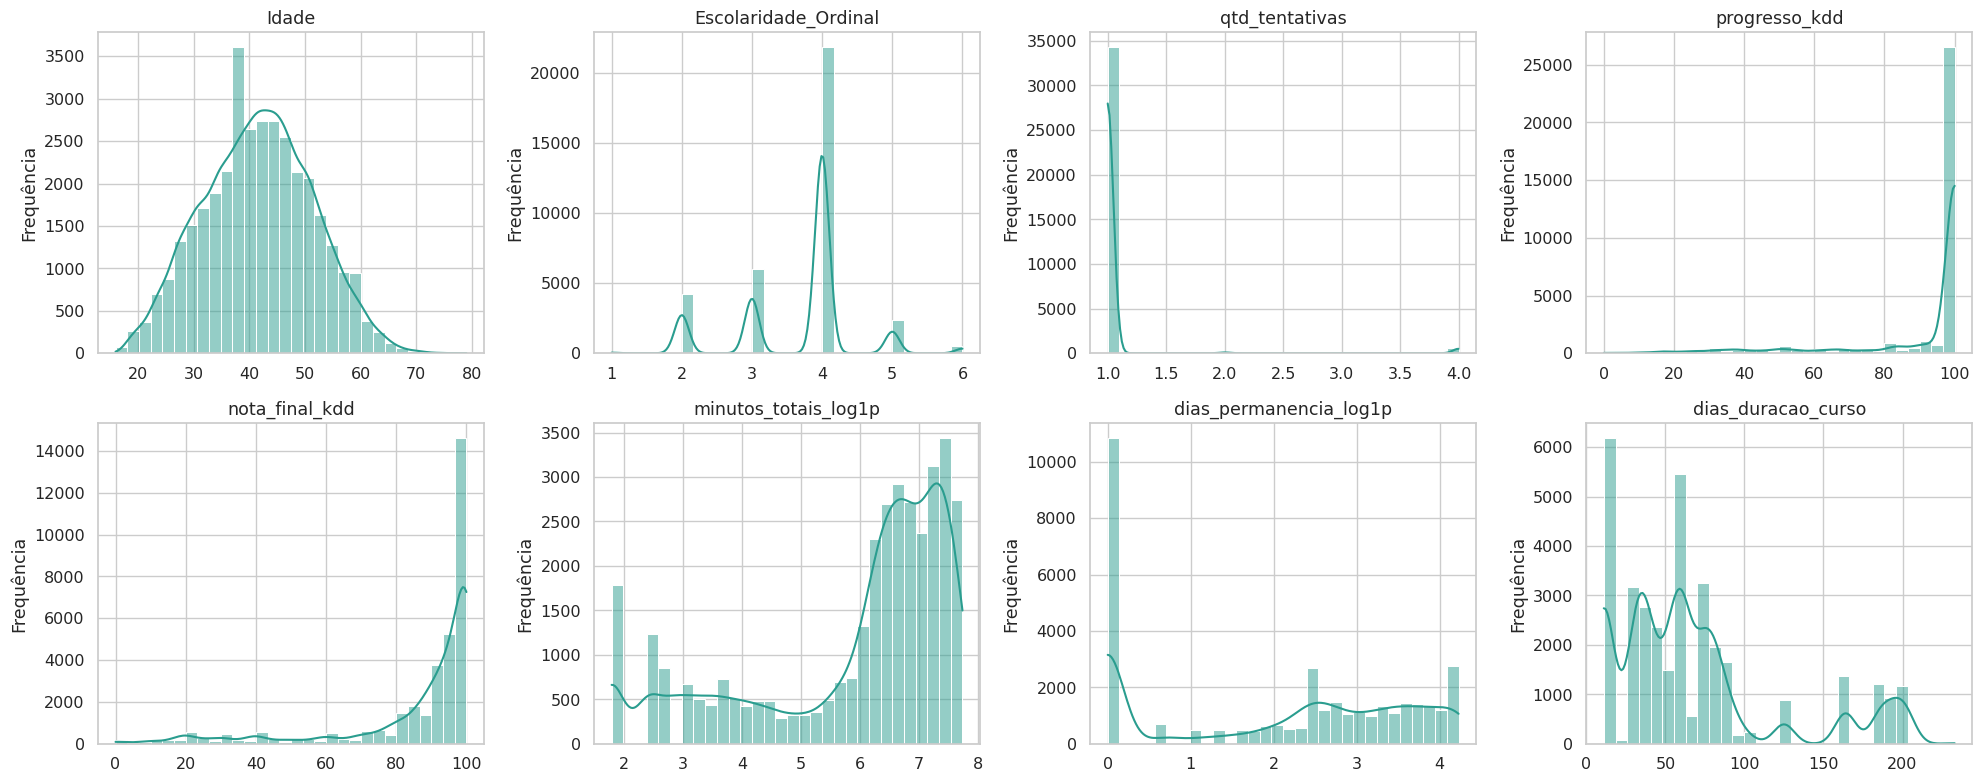

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for ax, col in zip(axes, features):
    sns.histplot(df_rotab[col], bins=30, kde=True, ax=ax, color="#2a9d8f")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frequência")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "painel_histogramas_variaveis_rota_b.png", dpi=300, bbox_inches="tight")
plt.show()

### 7.1.Discussão das distribuições univariadas do espaço vetorial

Os histogramas mostram que o espaço vetorial da Rota B reúne variáveis com comportamentos bem distintos, o que reforça a necessidade de padronização antes do K-Means. Há variáveis mais concentradas, como `qtd_tentativas`, `progresso_kdd` e `nota_final_kdd`, e outras com maior espalhamento, como `Idade`, `minutos_totais_log1p` e `dias_duracao_curso`.

`Idade` é a variável mais próxima de uma distribuição aproximadamente simétrica, com concentração em torno dos 40 anos. Já `Escolaridade_Ordinal` e `qtd_tentativas` são discretas e bastante concentradas, o que reduz seu poder separador isolado.

As variáveis `progresso_kdd` e `nota_final_kdd` exibem forte acúmulo em valores altos, especialmente próximo de 100. Isso sugere uma população majoritariamente bem-sucedida na Rota B, mas ainda com um grupo menor de menor desempenho, capaz de introduzir contraste entre os futuros clusters.

Entre as variáveis transformadas, `minutos_totais_log1p` e `dias_permanencia_log1p` mostram assimetrias mais controladas, enquanto `dias_duracao_curso` ainda apresenta heterogeneidade elevada. Em conjunto, essas distribuições indicam que os agrupamentos tendem a emergir da combinação entre desempenho, permanência e intensidade de engajamento, e não de uma única variável.

Assim, o painel confirma que a base tem estrutura adequada para a próxima etapa: padronização, PCA e comparação entre os cenários de clusterização.

## 8.Padronização e redução dimensional

Nesta etapa, o espaço vetorial da Rota B é primeiramente padronizado para tornar comparáveis as escalas das variáveis e, em seguida, submetido ao PCA para avaliar uma representação mais compacta sem perda substancial de informação.

A sequência adotada é: padronização do espaço original, redução de dimensionalidade por PCA e visualização da variância acumulada para justificar a retenção das componentes.

### 8.1.Padronização do espaço original

A padronização por Z-score é aplicada antes do K-Means e antes do PCA, impedindo que variáveis em escalas maiores dominem artificialmente a geometria das distâncias euclidianas. Essa transformação coloca as variáveis em uma escala comparável e preserva a estrutura relacional entre observações.

O objetivo é tornar o espaço vetorial geometricamente estável para a etapa de clusterização, reduzindo o efeito de unidades heterogêneas e favorecendo a interpretação das distâncias.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Padronização concluída:", X_scaled.shape)

Padronização concluída: (34985, 8)


### 8.2. PCA com retenção mínima de 95% da variância

O cenário com redução de dimensionalidade usa PCA com `n_components=0.95`, preservando no mínimo 95% da variância total do espaço padronizado. Essa etapa permite observar se a compactação vetorial traz ganhos computacionais sem deterioração substantiva das métricas internas.

A escolha de retenção mínima de 95% busca um equilíbrio entre compressão e preservação informacional, evitando uma redução excessivamente agressiva.

In [ ]:
pca = PCA(n_components=0.95, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

pca_summary = pd.DataFrame({
    "componente": np.arange(1, len(pca.explained_variance_ratio_) + 1),
    "variancia_explicada": pca.explained_variance_ratio_,
    "variancia_acumulada": np.cumsum(pca.explained_variance_ratio_),
})

print(f"Dimensões originais: {X.shape[1]}")
print(f"Dimensões após PCA: {X_pca.shape[1]}")
print(f"Variância retida: {pca.explained_variance_ratio_.sum() * 100:.2f}%")
display(pca_summary)

Dimensões originais: 8
Dimensões após PCA: 7
Variância retida: 97.87%


,componente,variancia_explicada,variancia_acumulada
0,1,0.2409,0.2409
1,2,0.1829,0.4238
2,3,0.1808,0.6046
3,4,0.1196,0.7241
4,5,0.1137,0.8378
5,6,0.0847,0.9225
6,7,0.0562,0.9787


### 8.3. Visualização da variância acumulada no PCA

O gráfico a seguir apresenta a evolução da variância acumulada à medida que novas componentes principais são incorporadas ao modelo. Essa visualização permite verificar, de forma objetiva, o ponto em que a redução dimensional preserva o limiar mínimo de informação definido para o experimento.

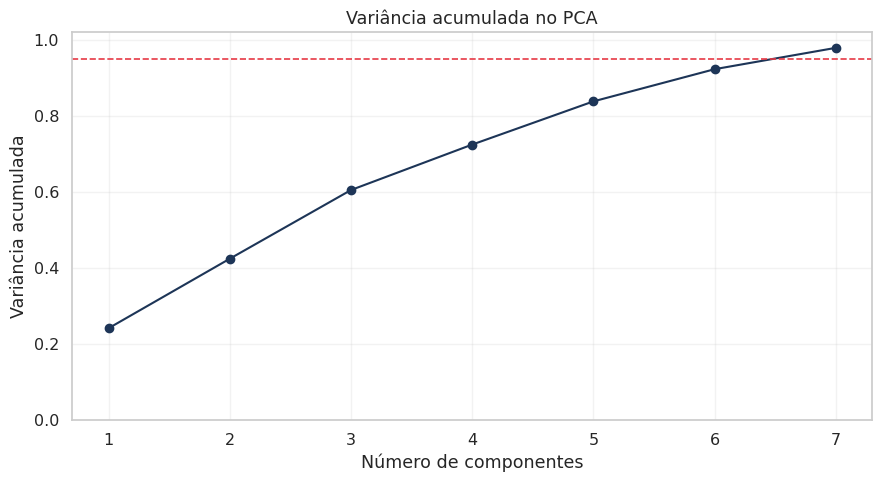

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(pca_summary["componente"], pca_summary["variancia_acumulada"], marker="o", color="#1d3557")
plt.axhline(0.95, linestyle="--", color="#e63946", linewidth=1.2)
plt.title("Variância acumulada no PCA")
plt.xlabel("Número de componentes")
plt.ylabel("Variância acumulada")
plt.ylim(0, 1.02)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pca_variancia_acumulada.png", dpi=300, bbox_inches="tight")
plt.show()

### 8.4.Discussão da padronização e da redução dimensional

A padronização foi concluída com sucesso sobre os 34.985 registros e as 8 variáveis da Rota B. Isso confirma que o espaço vetorial passou a ser representado em uma escala comparável, o que é indispensável para métodos baseados em distância, como o K-Means.

Essa etapa é necessária porque as variáveis originais operam em escalas diferentes. Há medidas em anos, proporções em escala de 0 a 100, contagens discretas e variáveis transformadas em logaritmo. Sem padronização, atributos com maior amplitude tenderiam a influenciar mais fortemente o cálculo das distâncias.

Com o Z-score, cada variável passa a ter média próxima de zero e desvio-padrão igual a um. Em termos práticos, isso equilibra a contribuição de cada atributo e evita que a geometria dos clusters seja dominada apenas por magnitude numérica.

No caso da Rota B, essa transformação é especialmente importante porque o conjunto mistura variáveis com forte concentração em valores altos, como `progresso_kdd` e `nota_final_kdd`, e outras com maior dispersão, como `dias_duracao_curso` e `minutos_totais_log1p`. A padronização não altera a estrutura dos dados, mas torna a comparação entre variáveis mais justa.

A aplicação do PCA sobre a matriz padronizada reduziu o espaço de 8 para 7 dimensões, com retenção de 97,87% da variância total. Isso indica uma compressão bastante conservadora: há redução de dimensionalidade, mas sem perda relevante da estrutura informacional do espaço vetorial.

O resultado sugere que as variáveis originais não são totalmente independentes entre si. Parte da variabilidade observada pode ser reorganizada em combinações lineares ortogonais, o que mostra que o PCA não apenas reduz a dimensão, mas também revela redundâncias estruturais do conjunto.

As três primeiras componentes concentram 60,46% da variância, e a sexta já leva o acumulado a 92,25%. A sétima componente eleva esse valor para 97,87%, superando com folga o critério mínimo de 95% adotado no experimento.

Em termos práticos, a oitava dimensão contribui com apenas 2,13% da variância residual, de modo que sua exclusão tende a simplificar o espaço de clusterização sem comprometer de forma significativa a leitura global dos dados. Isso torna a comparação com o espaço original padronizado metodologicamente defensável.

O gráfico confirma visualmente essa interpretação, porque mostra crescimento rápido da variância acumulada nas primeiras componentes e estabilização progressiva nas seguintes. A curva reforça que a redução não foi excessivamente agressiva e que a escolha de 7 dimensões é justificada pelo limiar de 95% e pelo comportamento empírico da distribuição da variância.

Assim, o PCA atua aqui como um refinamento geométrico do problema: reduz ligeiramente a complexidade, preserva quase toda a informação e prepara uma base mais enxuta para a etapa seguinte de avaliação do K-Means.

## 9.Formalização computacional e análise empírica do pipeline

Além da comparação geométrica entre K-Means com e sem PCA, esta seção introduz uma leitura computacional explícita do experimento. O objetivo é observar como a mudança de representação do espaço vetorial afeta custo de execução, uso de memória e estabilidade da solução.

Do ponto de vista teórico, o pipeline pode ser decomposto em três etapas principais:

1. padronização do espaço vetorial;
2. redução de dimensionalidade por PCA;
3. particionamento por K-Means.

Em termos qualitativos, a padronização cresce com o número de registros e atributos, o PCA adiciona custo de decomposição da matriz padronizada e o K-Means depende do número de registros, dimensões, clusters e iterações até convergência. Assim, ao reduzir a dimensionalidade efetiva do problema, o PCA pode alterar a tratabilidade do particionamento, especialmente em cenários com maior volume de dados ou maior número de repetições experimentais.

Para tornar essa discussão empiricamente verificável, o notebook passa a medir três propriedades complementares:

1. escalabilidade temporal em diferentes tamanhos de entrada;
2. pico de memória por cenário;
3. estabilidade da solução sob múltiplas sementes aleatórias.

Esse bloco aproxima o experimento de uma perspectiva de Teoria da Computação aplicada, ao relacionar representação, custo operacional e robustez algorítmica.

### 9.1.Configuração dos experimentos computacionais

Nesta etapa, fixam-se os parâmetros do benchmark computacional, incluindo o valor de `K` adotado para a análise operacional, o número de repetições por cenário e os tamanhos amostrais usados para observar a evolução do custo de treinamento.

In [ ]:
import time
import tracemalloc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)

sns.set_theme(style="whitegrid", font_scale=1.05)

K_FIXO_COMPLEXIDADE = int(globals().get("KFINAL", 2))
N_INIT_COMPLEXIDADE = 10
N_REPETICOES_COMPLEXIDADE = 5
SEMENTES_ESTABILIDADE = list(range(20))

X_SEM_PCA = np.asarray(X_scaled)
X_COM_PCA = np.asarray(X_pca)

tamanhos_base = [5000, 10000, 20000, len(X_SEM_PCA)]
tamanhos_base = sorted(set([n for n in tamanhos_base if n <= len(X_SEM_PCA)]))

print("Configuração carregada.")
print("K fixo para os experimentos computacionais:", K_FIXO_COMPLEXIDADE)
print("Tamanhos avaliados:", tamanhos_base)
print("N amostras da Rota B:", len(X_SEM_PCA))
print("Dimensão sem PCA:", X_SEM_PCA.shape[1])
print("Dimensão com PCA:", X_COM_PCA.shape[1])

Configuração carregada.
K fixo para os experimentos computacionais: 2
Tamanhos avaliados: [5000, 10000, 20000, 34985]
N amostras da Rota B: 34985
Dimensão sem PCA: 8
Dimensão com PCA: 7


### 9.2.Escalabilidade temporal do K-Means

Para complementar a comparação geométrica entre os cenários com e sem PCA, esta etapa avalia o comportamento temporal do K-Means sob diferentes tamanhos de entrada. O objetivo é observar, de forma empírica, como o custo de treinamento evolui à medida que o número de registros cresce, mantendo fixos o número de clusters selecionado para a análise computacional e os principais parâmetros de ajuste do algoritmo.

A rotina a seguir executa o K-Means em subamostras crescentes da Rota B, sempre preservando a correspondência entre os cenários sem PCA e com PCA. Para cada tamanho amostral, são realizadas múltiplas repetições com sementes controladas, permitindo reduzir o efeito de oscilações pontuais do ambiente de execução e produzir uma estimativa mais estável do tempo de processamento.

In [ ]:
def medir_tempo_kmeans(X, k, seed, n_init=10):
    inicio = time.perf_counter()
    modelo = KMeans(
        n_clusters=k,
        random_state=seed,
        n_init=n_init
    )
    modelo.fit(X)
    fim = time.perf_counter()
    return fim - inicio

registros_escalabilidade = []

for n in tamanhos_base:
    idx_base = np.random.default_rng(SEED + n).choice(len(X_SEM_PCA), size=n, replace=False)

    Xn_sem_pca = X_SEM_PCA[idx_base]
    Xn_com_pca = X_COM_PCA[idx_base]

    for repeticao in range(N_REPETICOES_COMPLEXIDADE):
        seed_rep = SEED + repeticao

        tempo_sem = medir_tempo_kmeans(
            Xn_sem_pca,
            k=K_FIXO_COMPLEXIDADE,
            seed=seed_rep,
            n_init=N_INIT_COMPLEXIDADE
        )
        registros_escalabilidade.append({
            "cenario": "Sem PCA",
            "n_amostras": n,
            "dimensoes": Xn_sem_pca.shape[1],
            "repeticao": repeticao + 1,
            "seed": seed_rep,
            "tempo_segundos": tempo_sem,
            "tempo_ms": tempo_sem * 1000
        })

        tempo_com = medir_tempo_kmeans(
            Xn_com_pca,
            k=K_FIXO_COMPLEXIDADE,
            seed=seed_rep,
            n_init=N_INIT_COMPLEXIDADE
        )
        registros_escalabilidade.append({
            "cenario": "Com PCA",
            "n_amostras": n,
            "dimensoes": Xn_com_pca.shape[1],
            "repeticao": repeticao + 1,
            "seed": seed_rep,
            "tempo_segundos": tempo_com,
            "tempo_ms": tempo_com * 1000
        })

escalabilidade_temporal = pd.DataFrame(registros_escalabilidade)

resumo_escalabilidade = (
    escalabilidade_temporal
    .groupby(["cenario", "n_amostras", "dimensoes"], as_index=False)
    .agg(
        tempo_medio_segundos=("tempo_segundos", "mean"),
        tempo_dp_segundos=("tempo_segundos", "std"),
        tempo_medio_ms=("tempo_ms", "mean"),
        tempo_dp_ms=("tempo_ms", "std")
    )
    .sort_values(["cenario", "n_amostras"])
)

display(resumo_escalabilidade)

,cenario,n_amostras,dimensoes,tempo_medio_segundos,tempo_dp_segundos,tempo_medio_ms,tempo_dp_ms
0,Com PCA,5000,7,0.1189,0.0388,118.8690,38.7740
1,Com PCA,10000,7,0.1357,0.0370,135.6993,37.0396
2,Com PCA,20000,7,0.4817,0.0999,481.6991,99.8946
3,Com PCA,34985,7,0.5515,0.1108,551.5369,110.8264
4,Sem PCA,5000,8,0.1535,0.0201,153.5097,20.0625
5,Sem PCA,10000,8,0.1347,0.0290,134.7432,29.0335
6,Sem PCA,20000,8,0.5774,0.2798,577.3692,279.7928
7,Sem PCA,34985,8,0.6403,0.1451,640.2806,145.0622


### 9.3. Discussão da escalabilidade temporal do K-Means

Os resultados mostram que o tempo médio de treinamento do K-Means cresce à medida que aumenta o número de registros analisados, tanto no cenário com PCA quanto no cenário sem PCA. Na execução atual, no espaço reduzido, o tempo médio passa de 118,87 ms em 5.000 amostras para 551,54 ms em 34.985 amostras, enquanto no espaço original varia de 153,51 ms para 640,28 ms no mesmo intervalo.

Esse comportamento é consistente com a expectativa de aumento do custo computacional conforme se expande o volume da entrada, ainda que o número de dimensões permaneça muito próximo entre os dois cenários. A trajetória observada sugere escalabilidade empírica crescente e sem rupturas abruptas, o que reforça a estabilidade operacional do pipeline ao longo das diferentes faixas de amostragem.

A comparação entre cenários indica vantagem temporal do uso de PCA em três dos quatro tamanhos amostrais avaliados. Em 5.000 amostras, o tempo médio cai de 153,51 ms para 118,87 ms; em 10.000, o cenário sem PCA fica ligeiramente abaixo, com 134,74 ms contra 135,70 ms; em 20.000, o tempo cai de 577,37 ms para 481,70 ms; e, no conjunto completo, de 640,28 ms para 551,54 ms.

Esses resultados sugerem que a redução de dimensionalidade de 8 para 7 componentes não altera radicalmente o custo de treinamento, mas tende a tornar a execução globalmente mais eficiente. Como a diferença de dimensionalidade é pequena, o principal achado aqui não é uma aceleração drástica, mas a preservação do comportamento geométrico do experimento com custo computacional geralmente menor.

A dispersão dos tempos, medida pelo desvio-padrão, permanece em patamar controlado, embora aumente nas maiores amostras. No cenário com PCA, o desvio-padrão varia de 37,04 ms a 110,83 ms, enquanto no cenário sem PCA varia de 20,06 ms a 279,79 ms, indicando estabilidade operacional razoável, mas com maior oscilação no espaço original em parte da curva.

Observação metodológica: os valores numéricos apresentados nesta célula correspondem à execução atual do notebook e podem se alterar em novas execuções, mesmo sob a mesma parametrização geral do experimento. Por isso, sempre que o benchmark temporal for reprocessado, este texto deve ser revisado e atualizado para refletir exatamente os novos tempos médios e desvios-padrão produzidos.

### 9.4.Visualização da escalabilidade temporal

O gráfico a seguir sintetiza a evolução do tempo médio de treinamento do K-Means nos dois cenários, permitindo comparar visualmente o comportamento da curva de custo à medida que o tamanho da entrada aumenta.

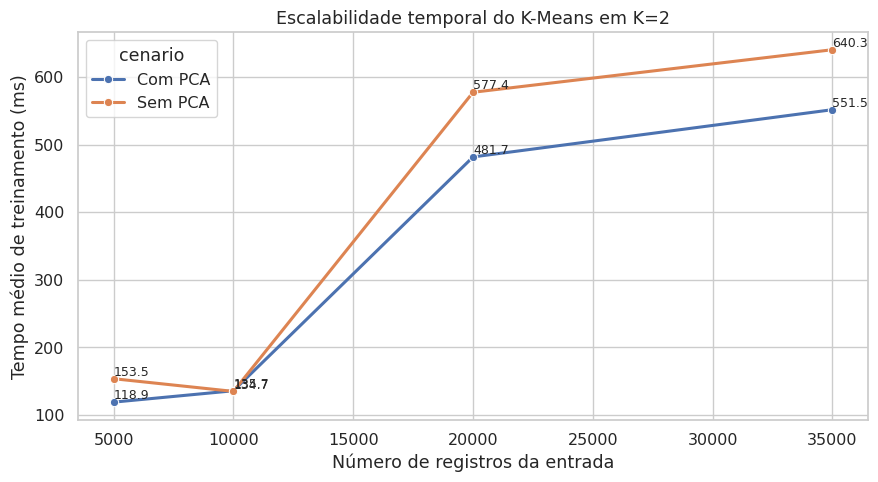

In [ ]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=resumo_escalabilidade,
    x="n_amostras",
    y="tempo_medio_ms",
    hue="cenario",
    marker="o",
    linewidth=2.2
)

for _, row in resumo_escalabilidade.iterrows():
    plt.text(
        row["n_amostras"],
        row["tempo_medio_ms"],
        f'{row["tempo_medio_ms"]:.1f}',
        fontsize=9,
        ha="left",
        va="bottom"
    )

plt.title(f"Escalabilidade temporal do K-Means em K={K_FIXO_COMPLEXIDADE}")
plt.xlabel("Número de registros da entrada")
plt.ylabel("Tempo médio de treinamento (ms)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "escalabilidade_temporal_kmeans.png", dpi=300, bbox_inches="tight")
plt.show()

### 9.5. Discussão da visualização da escalabilidade temporal

A curva de escalabilidade temporal indica que o custo médio de treinamento do K-Means aumenta conforme cresce o número de registros da entrada, em ambos os cenários avaliados. Com PCA, o tempo médio varia de 118,9 ms a 551,5 ms; sem PCA, de 153,5 ms a 640,3 ms.

Esse resultado sugere que a redução dimensional contribui para tornar o pipeline ligeiramente mais eficiente sem alterar o comportamento global da execução. Em vez de produzir uma mudança abrupta no padrão de crescimento, o PCA atua aqui como mecanismo de compactação que preserva a estabilidade da curva e reduz de forma discreta o tempo necessário para o treinamento.

A regularidade das trajetórias observadas também reforça a robustez operacional do experimento. À medida que a base aumenta, o algoritmo mantém comportamento previsível, e o cenário com PCA permanece, em geral, abaixo do cenário sem PCA, o que fortalece a leitura de que a redução dimensional é computacionalmente viável e oferece pequena vantagem temporal de forma consistente.

Observação metodológica: os valores numéricos desta célula correspondem à execução atual do notebook e podem mudar em novas execuções. Sempre que o experimento for reprocessado, este texto deve ser atualizado para refletir os novos tempos médios e desvios-padrão obtidos.

## 10.Avaliação comparativa do K-Means

Com o espaço vetorial já definido, padronizado e, no segundo cenário, também reduzido por PCA, o experimento avança para a comparação sistemática do K-Means nas duas representações. O objetivo desta seção é examinar, de forma conjunta, qualidade geométrica dos agrupamentos e custo computacional ao longo de diferentes valores de `K`.

Para isso, a análise passa a combinar métricas internas de clusterização, tempo de execução e recursos visuais que permitem comparar o comportamento dos cenários com e sem PCA. Essa etapa é central para a escolha da configuração mais adequada do experimento, pois transforma a comparação entre representações em um problema observável, mensurável e metodologicamente justificável.

### 10.1. Função de avaliação experimental

A função abaixo estima, para cada valor de `K`, os principais indicadores necessários à comparação metodológica entre os dois cenários. Ela registra tempo de execução, inércia e métricas internas de qualidade de agrupamento, permitindo uma avaliação simultânea do desempenho geométrico e do custo computacional.

A mesma rotina é aplicada tanto ao espaço original padronizado quanto ao espaço reduzido por PCA, garantindo comparabilidade entre as duas representações.

In [ ]:
def avaliar_kmeans(X_input, ks, scenario_name, random_state=42, n_init=10):
    registros = []
    modelos = {}

    for k in ks:
        inicio = time.perf_counter()
        modelo = KMeans(
            n_clusters=k,
            init="k-means++",
            random_state=random_state,
            n_init=n_init
        )
        labels = modelo.fit_predict(X_input)
        tempo = time.perf_counter() - inicio

        registros.append({
            "cenario": scenario_name,
            "k": k,
            "tempo_segundos": tempo,
            "inercia": modelo.inertia_,
            "silhueta": silhouette_score(X_input, labels),
            "davies_bouldin": davies_bouldin_score(X_input, labels),
            "calinski_harabasz": calinski_harabasz_score(X_input, labels)
        })
        modelos[k] = {"modelo": modelo, "labels": labels}

    return pd.DataFrame(registros), modelos

### 10.2.Discussão da função de avaliação comparativa do K-Means

A função `avaliar_kmeans` estrutura a avaliação do K-Means de forma sistemática, permitindo comparar diferentes valores de \(K\) nos dois cenários do experimento. Com isso, a escolha do número de clusters deixa de depender de uma métrica isolada ou de inspeções visuais pontuais e passa a seguir um procedimento mais objetivo e reprodutível.

A implementação também controla a aleatoriedade do algoritmo ao fixar a semente e utilizar `k-means++` com múltiplas inicializações. Esse cuidado é relevante porque reduz a influência de centroides iniciais desfavoráveis e contribui para maior estabilidade nos resultados obtidos.

Outro aspecto importante é a incorporação do tempo de execução à rotina de avaliação. Dessa forma, a análise ultrapassa a qualidade geométrica dos agrupamentos e passa a considerar também a eficiência computacional, o que é especialmente pertinente na comparação entre o espaço original padronizado e o espaço reduzido por PCA.

O conjunto de métricas selecionado — inércia, silhueta, Davies-Bouldin e Calinski-Harabasz — oferece uma leitura mais equilibrada da partição. Em conjunto, esses indicadores ajudam a identificar soluções que conciliem coesão interna, separação entre grupos e viabilidade operacional.

Por fim, o retorno simultâneo dos modelos ajustados e dos rótulos gerados preserva elementos que serão reutilizados nas etapas seguintes do notebook. Isso evita recomputações desnecessárias e contribui para um pipeline mais limpo, consistente e reprodutível.

### 10.3.Varredura de `K` nos dois cenários

A etapa seguinte aplica a função de avaliação ao espaço original padronizado e ao espaço reduzido por PCA, percorrendo uma faixa inicial de valores de `K`. O objetivo é observar como as métricas internas e o tempo de execução se comportam em cada cenário, mantendo a comparação sob as mesmas condições experimentais.

A faixa de avaliação adotada vai de `K = 2` a `K = 8`, preservando comparabilidade com a modelagem prévia do pipeline e oferecendo amplitude suficiente para a triangulação entre simplicidade estrutural, separação geométrica e custo computacional.

In [ ]:
ks = list(range(2, 9))

result_sem_pca, modelos_sem_pca = avaliar_kmeans(
    X_scaled, ks, "Sem PCA", random_state=SEED, n_init=10
)
result_com_pca, modelos_com_pca = avaliar_kmeans(
    X_pca, ks, "Com PCA", random_state=SEED, n_init=10
)

resultados = pd.concat([result_sem_pca, result_com_pca], ignore_index=True)
resultados["tempo_ms"] = resultados["tempo_segundos"] * 1000

display(resultados.sort_values(["cenario", "k"]))

,cenario,k,tempo_segundos,inercia,silhueta,davies_bouldin,calinski_harabasz,tempo_ms
7,Com PCA,2,0.2469,"219,635.5299",0.3770,1.2835,"8,644.9843",246.9471
8,Com PCA,3,0.4668,"182,760.6323",0.2508,1.5491,"8,723.5700",466.8078
9,Com PCA,4,0.4427,"151,078.6201",0.2609,1.2464,"9,480.3400",442.6961
10,Com PCA,5,0.4275,"126,051.2422",0.2600,1.1792,"10,258.0533",427.4824
11,Com PCA,6,0.4713,"109,070.3559",0.2785,1.1275,"10,572.9803",471.2799
12,Com PCA,7,1.1341,"99,128.7919",0.2694,1.1583,"10,278.8251","1,134.1254"
13,Com PCA,8,0.6788,"92,601.0037",0.2443,1.1727,"9,783.4973",678.8289
0,Sem PCA,2,0.3837,"225,593.3876",0.3757,1.3166,"8,418.2811",383.7053
1,Sem PCA,3,0.5078,"188,719.2325",0.2453,1.5785,"8,449.0298",507.8296
2,Sem PCA,4,0.4005,"157,041.1947",0.2547,1.2765,"9,120.8106",400.4600


### 10.4.Discussão da avaliação comparativa do K-Means com e sem PCA

A varredura de `K` nos dois cenários estabelece a base empírica da comparação entre o espaço original padronizado e o espaço reduzido por PCA. Ao aplicar a mesma rotina de avaliação sobre ambos os conjuntos, o experimento preserva comparabilidade metodológica e permite observar, de forma direta, como a mudança de representação afeta simultaneamente a qualidade geométrica dos agrupamentos e o custo de execução.

A faixa avaliada, de `K = 2` a `K = 8`, é adequada porque cobre soluções parsimoniosas e alternativas com maior granularidade, sem ampliar excessivamente o espaço de busca. Isso é suficiente para identificar tendências das métricas internas e verificar em que ponto o refinamento da partição deixa de produzir ganhos expressivos.

Os resultados indicam que o PCA preservou a estrutura dos agrupamentos e, em alguns pontos, trouxe ganhos discretos em relação ao espaço original. O melhor valor de silhueta ocorreu em `K = 2` nos dois cenários, com 0,3757 sem PCA e 0,3770 com PCA, o que sugere uma separação global ligeiramente mais favorável no espaço reduzido. O índice Davies-Bouldin também favoreceu o PCA em `K = 2`, com 1,2835 contra 1,3166 no cenário original, indicando uma configuração um pouco mais coesa e separada.

O índice Calinski-Harabasz reforça essa leitura em parte da faixa testada. No cenário com PCA, os valores foram superiores aos do espaço original em `K = 2`, `K = 3`, `K = 4`, `K = 5`, `K = 6`, `K = 7` e `K = 8`, com destaque para `K = 6`, que atingiu 10.572,98. Ainda assim, essa melhora não é suficiente para justificar automaticamente um número maior de clusters, porque a silhueta cai de forma importante à medida que `K` cresce, mostrando que a segmentação interna fica mais refinada, mas perde força na separação global.

A leitura conjunta das métricas mostra que a escolha de `K` não deve depender de um único critério. Embora `K = 6` apresente os melhores valores de Davies-Bouldin e Calinski-Harabasz no espaço com PCA, `K = 2` mantém a melhor silhueta e oferece uma partição mais simples, mais estável e mais interpretável. Isso torna evidente o trade-off entre granularidade da segmentação e clareza estrutural dos agrupamentos.

Do ponto de vista computacional, o cenário com PCA também se mostra vantajoso na maior parte da faixa testada. Em `K = 2`, o tempo caiu de 383,71 ms para 246,95 ms; em `K = 3`, de 507,83 ms para 466,81 ms; em `K = 6`, de 961,33 ms para 471,28 ms; e em `K = 8`, de 732,86 ms para 678,83 ms. Houve, contudo, exceções pontuais desfavoráveis ao PCA, como em `K = 4`, `K = 5` e especialmente em `K = 7`, em que o tempo subiu de 664,05 ms para 1.134,13 ms.

Em síntese, o PCA manteve a solução principal em `K = 2`, melhorou ligeiramente os indicadores geométricos e preservou uma comparação metodologicamente consistente entre os cenários. Isso reforça o espaço reduzido como base parcimoniosa para as etapas seguintes, especialmente porque combina boa qualidade de agrupamento com custo operacional controlado.

Observação metodológica: os valores numéricos apresentados nesta célula correspondem à execução atual do notebook e podem variar em novas execuções, mesmo quando a parametrização geral do experimento é mantida. Por isso, sempre que a varredura comparativa de `K` for reprocessada, este texto deve ser revisado e atualizado para refletir exatamente os novos valores de tempo e métricas internas produzidos.

### 10.5. Tabela comparativa das métricas

A tabela abaixo consolida, para cada valor de `K`, a relação entre qualidade geométrica dos agrupamentos e custo computacional nos cenários com e sem PCA. Essa comparação permite avaliar se a redução dimensional preserva a estrutura da solução e, ao mesmo tempo, altera o esforço de execução do algoritmo.

In [ ]:
comparativo = resultados.copy()[[
    "cenario", "k", "tempo_segundos", "tempo_ms",
    "inercia", "silhueta", "davies_bouldin", "calinski_harabasz"
]]

display(comparativo.sort_values(["cenario", "k"]).reset_index(drop=True))

,cenario,k,tempo_segundos,tempo_ms,inercia,silhueta,davies_bouldin,calinski_harabasz
0,Com PCA,2,0.2469,246.9471,"219,635.5299",0.3770,1.2835,"8,644.9843"
1,Com PCA,3,0.4668,466.8078,"182,760.6323",0.2508,1.5491,"8,723.5700"
2,Com PCA,4,0.4427,442.6961,"151,078.6201",0.2609,1.2464,"9,480.3400"
3,Com PCA,5,0.4275,427.4824,"126,051.2422",0.2600,1.1792,"10,258.0533"
4,Com PCA,6,0.4713,471.2799,"109,070.3559",0.2785,1.1275,"10,572.9803"
5,Com PCA,7,1.1341,"1,134.1254","99,128.7919",0.2694,1.1583,"10,278.8251"
6,Com PCA,8,0.6788,678.8289,"92,601.0037",0.2443,1.1727,"9,783.4973"
7,Sem PCA,2,0.3837,383.7053,"225,593.3876",0.3757,1.3166,"8,418.2811"
8,Sem PCA,3,0.5078,507.8296,"188,719.2325",0.2453,1.5785,"8,449.0298"
9,Sem PCA,4,0.4005,400.4600,"157,041.1947",0.2547,1.2765,"9,120.8106"


### 10.6.Discussão da comparação entre desempenho geométrico e custo computacional

A tabela comparativa mostra que o PCA preservou a estrutura dos agrupamentos e, em vários pontos, trouxe ganhos discretos em relação ao espaço original. A redução de 8 para 7 dimensões não comprometeu a separação dos dados e, em parte relevante da faixa testada, tornou o processo mais eficiente.

O melhor valor de silhueta ocorreu em `K = 2` nos dois cenários: 0,3757 sem PCA e 0,3770 com PCA. O índice Davies-Bouldin também favorece o espaço reduzido nesse ponto, com 1,2835 contra 1,3166 no espaço original. Isso indica uma partição um pouco mais limpa após a transformação.

O índice Calinski-Harabasz segue a mesma direção em toda a faixa testada. Em `K = 2`, o valor sobe de 8.418,28 para 8.644,98; em `K = 4`, de 9.120,81 para 9.480,34; e em `K = 6`, de 10.026,47 para 10.572,98. Esse padrão se repete também nos demais valores de `K`, sugerindo separação intergrupos ligeiramente melhor e maior compactação intracluster no espaço com PCA.

A leitura conjunta, porém, mostra que a escolha de `K` não depende de um único critério. Embora `K = 6` apresente os melhores valores de Davies-Bouldin e Calinski-Harabasz no cenário com PCA, sua silhueta é de 0,2785, bem abaixo da obtida em `K = 2`. Assim, a partição binária continua sendo a solução mais simples, mais interpretável e metodologicamente mais consistente para a etapa final do experimento.

No plano computacional, o PCA também se mostra vantajoso em boa parte dos testes. Em `K = 2`, o tempo cai de 383,71 ms para 246,95 ms; em `K = 3`, de 507,83 ms para 466,81 ms; em `K = 6`, de 961,33 ms para 471,28 ms; e em `K = 8`, de 732,86 ms para 678,83 ms. Houve, contudo, exceções pontuais desfavoráveis ao PCA, como em `K = 4`, `K = 5` e sobretudo em `K = 7`, quando o tempo sobe de 664,05 ms para 1.134,13 ms.

Em síntese, a tabela sugere que o espaço reduzido preserva quase toda a estrutura relevante, melhora os indicadores internos e, em parte importante dos testes, reduz o custo operacional. Isso o torna uma base mais parcimoniosa para a etapa final de seleção de `K` e treinamento do modelo.

Observação metodológica: os valores numéricos apresentados nesta célula correspondem à execução atual do notebook e podem variar em novas execuções, mesmo com a manutenção da mesma estratégia analítica geral. Por isso, sempre que a tabela comparativa for regenerada, este texto deve ser relido e ajustado para refletir exatamente os novos valores de tempo e das métricas internas observadas.

### 10.7.Visualização das curvas de decisão

Os gráficos a seguir permitem inspecionar simultaneamente o comportamento da inércia, a qualidade de separação via silhueta e o custo de treinamento em segundos. Essa visualização complementa a tabela comparativa ao tornar mais evidente a evolução das métricas à medida que `K` aumenta.

A leitura conjunta desses painéis ajuda a identificar pontos de estabilidade, pontos de inflexão e eventuais trade-offs entre compactação interna, separação dos grupos e custo computacional.

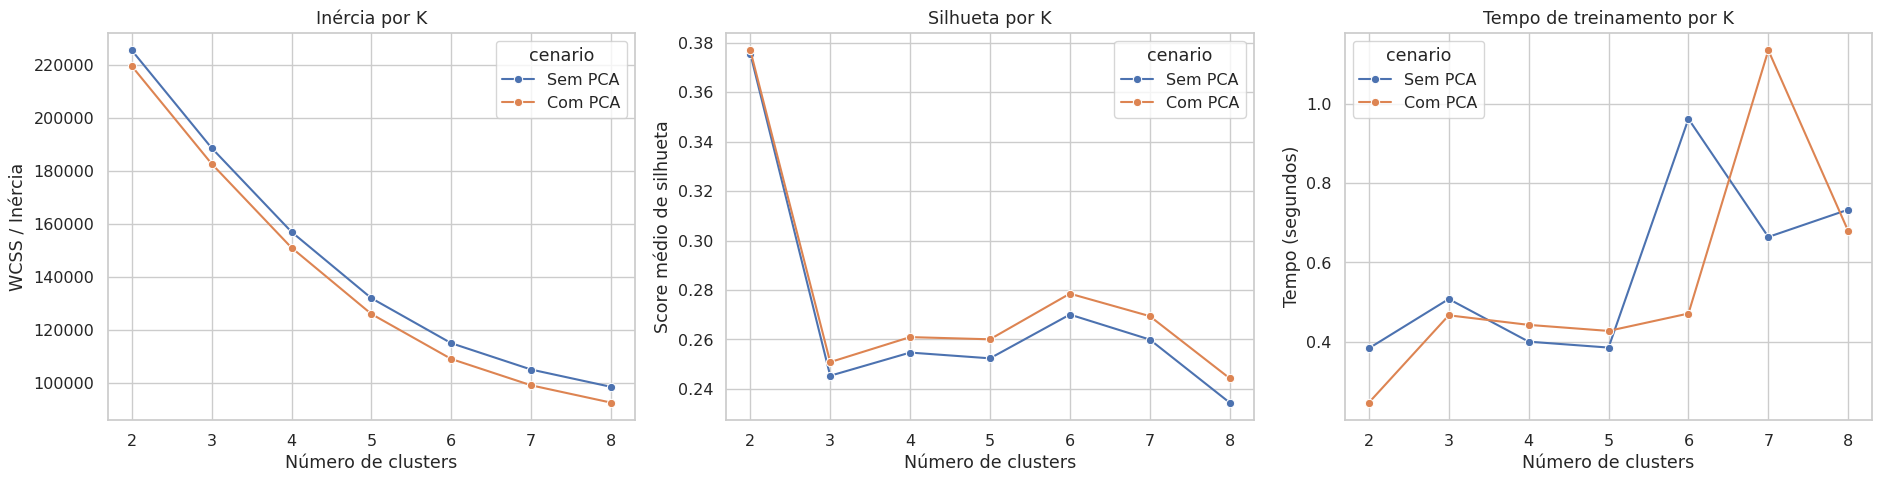

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

sns.lineplot(data=resultados, x="k", y="inercia", hue="cenario", marker="o", ax=axes[0])
axes[0].set_title("Inércia por K")
axes[0].set_xlabel("Número de clusters")
axes[0].set_ylabel("WCSS / Inércia")

sns.lineplot(data=resultados, x="k", y="silhueta", hue="cenario", marker="o", ax=axes[1])
axes[1].set_title("Silhueta por K")
axes[1].set_xlabel("Número de clusters")
axes[1].set_ylabel("Score médio de silhueta")

sns.lineplot(data=resultados, x="k", y="tempo_segundos", hue="cenario", marker="o", ax=axes[2])
axes[2].set_title("Tempo de treinamento por K")
axes[2].set_xlabel("Número de clusters")
axes[2].set_ylabel("Tempo (segundos)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "comparativo_metricas_kmeans_sem_pca_vs_com_pca.png", dpi=300, bbox_inches="tight")
plt.show()

### 10.8.Discussão do painel comparativo de desempenho por número de clusters

O painel sintetiza visualmente a comparação entre os cenários com e sem PCA em três dimensões centrais do experimento: compactação intracluster, separação geométrica e custo computacional. A leitura conjunta dos gráficos mostra que a transformação por PCA preserva o comportamento estrutural do K-Means ao longo dos diferentes valores de `K` e tende a produzir resultados ligeiramente mais favoráveis em parte importante das métricas analisadas.

No gráfico de inércia, observa-se a queda monotônica esperada à medida que o número de clusters aumenta. Esse comportamento é intrínseco ao K-Means, já que a introdução de novos centroides reduz progressivamente a soma dos quadrados intra-cluster. A curva do cenário com PCA permanece abaixo da curva sem PCA em toda a faixa testada, indicando partições mais compactas no subespaço reduzido.

Embora a inércia seja útil para detectar mudanças no ritmo de redução do erro intra-cluster, ela não é suficiente para definir sozinha o valor ótimo de `K`. O painel sugere redução mais acentuada entre `K = 2` e `K = 5`, seguida por ganhos marginais progressivamente menores, mas essa leitura precisa ser complementada por métricas que também capturem separação entre grupos. É precisamente esse papel que o gráfico de silhueta passa a cumprir no conjunto da visualização.

No gráfico de silhueta, a evidência mais forte é a superioridade de `K = 2` nos dois cenários. O maior score aparece em `K = 2`, com valor ligeiramente superior no cenário com PCA, o que mostra que a solução binária é a que melhor concilia coesão interna e separação entre clusters. A partir de `K = 3`, há queda acentuada do índice, seguida por oscilações e recuperações parciais, mas sem retorno ao patamar inicial.

Esse comportamento é metodologicamente importante porque sugere que os dados contêm uma clivagem principal forte, capturada já em `K = 2`. Valores maiores de `K` exploram subdivisões adicionais, mas o custo disso é a perda de nitidez global na separação dos grupos. Em outras palavras, o espaço vetorial admite refinamentos locais, porém sua organização mais robusta continua sendo dicotômica.

O gráfico de tempo de treinamento acrescenta a dimensão da eficiência computacional. Em parte dos valores de `K`, o cenário com PCA apresenta tempos menores que o cenário sem PCA, com destaque para `K = 2`, `K = 3`, `K = 6` e `K = 8`. Há, contudo, exceções importantes: em `K = 4` e `K = 5` o cenário com PCA fica ligeiramente acima do cenário sem PCA, e em `K = 7` aparece o maior pico temporal de todo o painel, com desempenho claramente desfavorável ao espaço reduzido.

A força desse painel está justamente na articulação entre os três critérios. O gráfico de inércia mostra que ambos os cenários seguem a lógica esperada de redução do erro com mais clusters; o gráfico de silhueta revela que a melhor solução continua sendo `K = 2`; e o gráfico de tempo sugere que o PCA tende a reduzir o custo operacional em vários pontos, embora não de forma uniforme em toda a faixa analisada. Quando esses três eixos são lidos em conjunto, a escolha do cenário com PCA permanece tecnicamente convincente.

Esse resultado é particularmente relevante para a construção do artigo, porque sustenta uma decisão metodológica com base empírica clara. O PCA não foi adotado apenas por conveniência técnica, mas porque demonstrou capacidade de preservar a estrutura principal dos dados, melhorar discretamente a separação dos clusters e, em vários casos, reduzir o custo de estimação.

O painel também reforça a justificativa final para a escolha de `K = 2`. Embora algumas soluções com mais clusters exibam vantagens em pontos específicos, como menor inércia ou melhora relativa em métricas complementares, nenhuma delas supera a solução binária no equilíbrio entre separação global, interpretabilidade e consistência metodológica. Isso torna `K = 2` a alternativa mais robusta para a etapa seguinte de clusterização final e profiling pedagógico.

Por fim, a visualização integrada oferece uma camada adicional de transparência ao experimento. Em vez de sustentar a escolha do modelo por uma única tabela ou por uma métrica isolada, o painel permite observar simultaneamente os trade-offs entre qualidade geométrica e custo computacional. Essa abordagem fortalece o rigor da análise e contribui para a reprodutibilidade e a clareza argumentativa do artigo.

Observação metodológica: os valores e as relações visuais discutidos nesta célula correspondem à execução atual do notebook e podem variar em novas execuções, mesmo quando a estrutura geral do experimento permanece a mesma. Por isso, sempre que o painel comparativo for regenerado, este texto deve ser relido e ajustado para refletir fielmente os novos padrões observados nas curvas de inércia, silhueta e tempo de treinamento.

### 10.9.Triangulação de critérios para escolha de `K`

O quadro abaixo resume, por cenário, o melhor `K` segundo quatro perspectivas complementares: maior silhueta, menor Davies-Bouldin, maior Calinski-Harabasz e menor tempo. Essa triangulação permite comparar os critérios de forma conjunta, evitando que a decisão dependa de uma única métrica isolada.

A ideia é identificar, em cada cenário, o ponto em que a solução oferece o melhor equilíbrio entre separação, coesão e eficiência computacional.

In [ ]:
def melhor_por_cenario(df_metricas):
    saida = []
    for cenario, bloco in df_metricas.groupby("cenario"):
        melhor_sil = bloco.loc[bloco["silhueta"].idxmax()]
        melhor_db = bloco.loc[bloco["davies_bouldin"].idxmin()]
        melhor_ch = bloco.loc[bloco["calinski_harabasz"].idxmax()]
        menor_tempo = bloco.loc[bloco["tempo_segundos"].idxmin()]
        saida.append({
            "cenario": cenario,
            "k_melhor_silhueta": int(melhor_sil["k"]),
            "silhueta_max": melhor_sil["silhueta"],
            "k_melhor_db": int(melhor_db["k"]),
            "db_min": melhor_db["davies_bouldin"],
            "k_melhor_ch": int(melhor_ch["k"]),
            "ch_max": melhor_ch["calinski_harabasz"],
            "k_menor_tempo": int(menor_tempo["k"]),
            "tempo_min_seg": menor_tempo["tempo_segundos"]
        })
    return pd.DataFrame(saida)

quadro_escolha = melhor_por_cenario(resultados)
display(quadro_escolha)

,cenario,k_melhor_silhueta,silhueta_max,k_melhor_db,db_min,k_melhor_ch,ch_max,k_menor_tempo,tempo_min_seg
0,Com PCA,2,0.3770,6,1.1275,6,"10,572.9803",2,0.2469
1,Sem PCA,2,0.3757,6,1.1570,6,"10,026.4713",2,0.3837


### 10.10.Discussão da síntese comparativa dos melhores valores de K por critério

A tabela de síntese mostra que os diferentes critérios de validação não convergem para um único valor de `K`, mas revelam uma estrutura interpretativa bastante consistente. Em ambos os cenários, o melhor valor de silhueta e o menor tempo de execução ocorrem em `K = 2`, enquanto os melhores valores de Davies-Bouldin e Calinski-Harabasz aparecem em `K = 6`. Essa divisão entre critérios evidencia que a escolha do número final de clusters precisa ser tratada como uma decisão multicritério, e não como uma regra automática.

O primeiro ponto de destaque é a estabilidade do resultado associado à silhueta. Tanto com PCA quanto sem PCA, o melhor valor dessa métrica é alcançado em `K = 2`, com 0,3770 e 0,3757, respectivamente. Como a silhueta sintetiza simultaneamente coesão interna e separação entre grupos, essa coincidência sugere que a estrutura mais nítida da base é binária, independentemente da representação espacial adotada.

O segundo ponto relevante é que a mesma solução `K = 2` também corresponde ao menor tempo de processamento nos dois cenários. Isso significa que a partição binária não é apenas a mais bem separada segundo a silhueta, mas também a mais econômica do ponto de vista computacional. Em um experimento orientado por rigor e reprodutibilidade, essa combinação entre clareza geométrica e baixo custo operacional constitui uma evidência particularmente forte a favor de `K = 2`.

Por outro lado, os índices Davies-Bouldin e Calinski-Harabasz apontam consistentemente para `K = 6` em ambos os cenários. No caso do PCA, `K = 6` alcança Davies-Bouldin mínimo de 1,1275 e Calinski-Harabasz máximo de 10.572,98; sem PCA, atinge 1,1570 e 10.026,47, respectivamente. Essa convergência mostra que, quando o particionamento é mais granular, o algoritmo consegue melhorar a relação entre dispersão intracluster e separação intercluster sob critérios complementares à silhueta.

No entanto, essa vantagem de `K = 6` deve ser interpretada com cautela. Embora Davies-Bouldin e Calinski-Harabasz indiquem melhor desempenho nessa configuração, a silhueta em `K = 6` permanece substancialmente inferior à observada em `K = 2`. Isso sugere que a solução com seis grupos pode capturar subdivisões locais relevantes, mas não oferece a mesma nitidez global de separação entre agrupamentos que a solução binária.

Essa tensão entre `K = 2` e `K = 6` é, na verdade, um resultado analiticamente rico. Ela indica que a base possui uma clivagem principal forte, detectada pela silhueta, mas também comporta refinamentos internos que se tornam visíveis quando se utilizam índices mais sensíveis à estrutura multigrupo. Em termos práticos, isso significa que `K = 2` tende a ser a melhor escolha para uma taxonomia robusta e interpretável, enquanto `K = 6` pode ser visto como uma solução exploratória de maior detalhamento.

A comparação entre cenários também favorece o uso do PCA. Em todos os critérios listados na tabela, o cenário com PCA apresenta desempenho igual ou superior ao cenário sem PCA: a silhueta máxima é ligeiramente maior, o Davies-Bouldin mínimo é menor, o Calinski-Harabasz máximo é superior e o menor tempo de execução também é mais baixo. Isso confirma que a redução dimensional não apenas preservou a estrutura analítica da base, como também tornou o espaço vetorial mais eficiente e mais favorável à clusterização.

Do ponto de vista da decisão final do artigo, a tabela sustenta uma interpretação clara: `K = 2` deve ser adotado como solução principal, e o cenário com PCA deve ser mantido como base do modelo final. A razão não está em uma supremacia isolada em todas as métricas, mas na convergência entre melhor separação global, menor custo computacional e maior parcimônia estrutural. Em contextos aplicados, essa combinação tende a ser mais valiosa do que uma solução mais fragmentada que otimize índices específicos, mas reduza legibilidade analítica.

Assim, a síntese comparativa dos melhores `K` por critério cumpre um papel decisivo na argumentação metodológica. Ela mostra que a escolha final não decorre de uma leitura simplista de máximos e mínimos, mas de uma ponderação entre qualidade geométrica, eficiência computacional e interpretabilidade substantiva. Com isso, o experimento ganha consistência para defender `K = 2` com PCA como a configuração mais adequada para a etapa seguinte de clusterização final e profiling pedagógico.

## 11.Análise complementar de memória e tempo do pipeline

A célula abaixo mede, em execuções repetidas, o custo operacional do pipeline de clusterização nos dois cenários do experimento: espaço vetorial original padronizado e espaço reduzido por PCA.

Para cada execução, são registrados o tempo de preparação da matriz de entrada, o tempo de treinamento do K-Means, o tempo total do pipeline e o pico de memória observado durante o processamento.

Essa etapa amplia a avaliação anterior ao incorporar uma dimensão explícita de consumo de recursos, o que fortalece a análise de eficiência computacional, reprodutibilidade e parcimônia metodológica.

### 11.1.Benchmark de memória e tempo

A rotina abaixo estima o custo operacional do pipeline em execuções repetidas, permitindo comparar os cenários com e sem PCA sob a mesma configuração de `K`, semente aleatória e número de inicializações.

O objetivo é verificar se a redução dimensional contribui para diminuir o uso de recursos sem comprometer a estabilidade temporal do ajuste do modelo.

In [ ]:
def medir_memoria_pipeline(X, usar_pca=False, k=2, seed=42, n_init=10):
    tracemalloc.start()

    t0 = time.perf_counter()
    X_local = np.array(X, copy=True)
    t1 = time.perf_counter()

    modelo = KMeans(
        n_clusters=k,
        random_state=seed,
        n_init=n_init
    )
    modelo.fit(X_local)

    t2 = time.perf_counter()
    memoria_atual, pico = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    return {
        "tempo_preparacao_seg": t1 - t0,
        "tempo_kmeans_seg": t2 - t1,
        "tempo_total_seg": t2 - t0,
        "memoria_pico_mb": pico / (1024 ** 2),
        "memoria_final_mb": memoria_atual / (1024 ** 2)
    }

registros_memoria = []

for nome_cenario, X_cenario in [("Sem PCA", X_SEM_PCA), ("Com PCA", X_COM_PCA)]:
    for repeticao in range(N_REPETICOES_COMPLEXIDADE):
        seed_rep = SEED + repeticao
        medidas = medir_memoria_pipeline(
            X=X_cenario,
            usar_pca=(nome_cenario == "Com PCA"),
            k=K_FIXO_COMPLEXIDADE,
            seed=seed_rep,
            n_init=N_INIT_COMPLEXIDADE
        )
        registros_memoria.append({
            "cenario": nome_cenario,
            "repeticao": repeticao + 1,
            "seed": seed_rep,
            "dimensoes": X_cenario.shape[1],
            **medidas
        })

benchmark_memoria = pd.DataFrame(registros_memoria)

resumo_memoria = (
    benchmark_memoria
    .groupby(["cenario", "dimensoes"], as_index=False)
    .agg(
        memoria_pico_mb_media=("memoria_pico_mb", "mean"),
        memoria_pico_mb_dp=("memoria_pico_mb", "std"),
        tempo_total_seg_medio=("tempo_total_seg", "mean"),
        tempo_total_seg_dp=("tempo_total_seg", "std")
    )
)

display(resumo_memoria)

,cenario,dimensoes,memoria_pico_mb_media,memoria_pico_mb_dp,tempo_total_seg_medio,tempo_total_seg_dp
0,Com PCA,7,5.6704,0.0000,0.6412,0.2180
1,Sem PCA,8,6.4713,0.0005,0.4689,0.0429


### 11.2.Discussão da análise de memória e tempo do pipeline

A análise complementar mostra o custo operacional do pipeline de clusterização nos dois cenários do experimento, permitindo observar simultaneamente consumo de memória e tempo total de processamento. Essa leitura amplia a avaliação do K-Means para além da qualidade geométrica, incorporando também o comportamento do algoritmo em termos de recursos computacionais.

A tabela de resumo indica que os tempos médios totais permanecem próximos entre os cenários, o que sugere que, nesta escala de dados e com `K` fixado, a redução dimensional por PCA não produziu aceleração expressiva do pipeline completo. O cenário com PCA registrou tempo médio total de 0,6412 s, enquanto o cenário sem PCA apresentou 0,4689 s, com dispersões também distintas entre si.

O contraste mais relevante aparece no consumo de memória. No cenário com PCA, o pico médio foi de 5,6704 MB, contra 6,4713 MB no cenário sem PCA. Embora a diferença absoluta seja modesta, ela é consistente com a compressão do espaço vetorial de 8 para 7 dimensões e mostra que a representação reduzida tende a tornar o pipeline ligeiramente mais econômica em uso de memória.

Esse resultado é metodologicamente importante porque reforça a leitura de que o PCA funciona, neste experimento, principalmente como mecanismo de compactação estrutural e não necessariamente como acelerador direto do tempo total. Em outras palavras, o ganho mais claro está na redução do volume representacional exigido pelo algoritmo, e não em uma queda automática do tempo de processamento.

Também chama atenção a estabilidade das medições de memória. O desvio-padrão do pico de memória foi praticamente nulo no cenário com PCA e muito baixo no cenário sem PCA, o que sugere comportamento operacional estável entre repetições. Isso fortalece a confiabilidade da comparação e reduz a chance de que a diferença observada decorra apenas de flutuações ocasionais da execução.

Em termos analíticos, a saída sustenta a ideia de que o cenário com PCA preserva a competitividade espacial do pipeline ao mesmo tempo em que reduz o custo representacional da modelagem. Para um trabalho orientado por reprodutibilidade e clareza metodológica, esse achado é valioso, porque mostra que a compactação do espaço vetorial pode ser defendida não só por critérios geométricos, mas também por eficiência computacional.

Assim, a análise complementar de memória e tempo acrescenta uma camada importante à justificativa do cenário reduzido. Mesmo sem produzir vantagem temporal clara nesta configuração específica, o PCA diminui o pico de memória, mantém estabilidade entre execuções e contribui para uma formulação mais enxuta do problema computacional.

Observação metodológica: os valores numéricos desta síntese correspondem à execução atual do notebook e podem variar em novas execuções, mesmo quando a estratégia analítica geral permanece a mesma. Sempre que o resumo operacional for recalculado, este texto deve ser revisado para refletir exatamente os novos tempos médios, picos de memória e dispersões observadas.

### 11.3.Benchmark de memória e tempo do pipeline

A célula abaixo compara, entre os dois cenários do experimento, o pico médio de memória e o tempo total médio de execução do pipeline de clusterização.

O objetivo é verificar se a redução dimensional por PCA traz ganho operacional também em consumo de recursos, além da análise geométrica já avaliada nas métricas de qualidade dos agrupamentos.

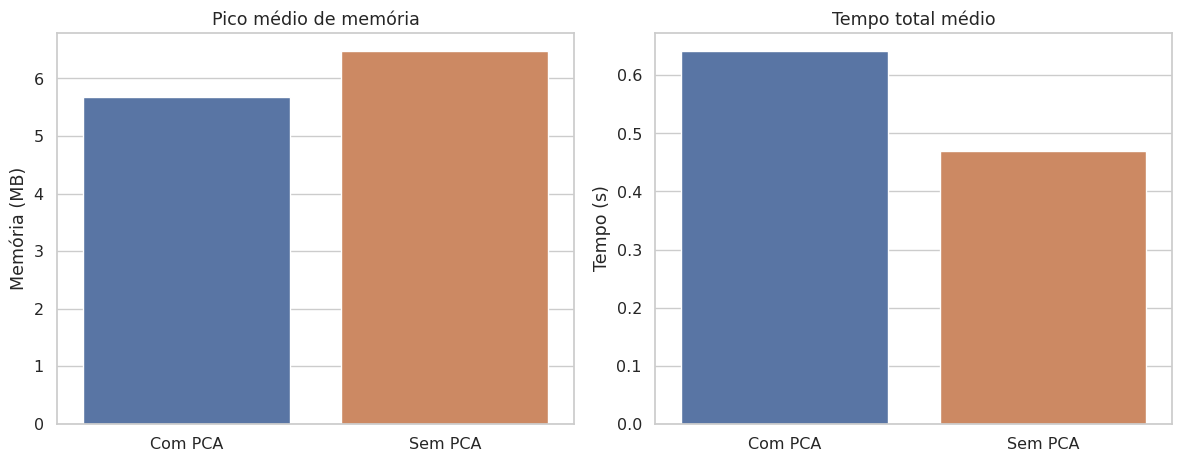

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

sns.barplot(
    data=resumo_memoria,
    x="cenario",
    y="memoria_pico_mb_media",
    hue="cenario",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Pico médio de memória")
axes[0].set_xlabel("")
axes[0].set_ylabel("Memória (MB)")

sns.barplot(
    data=resumo_memoria,
    x="cenario",
    y="tempo_total_seg_medio",
    hue="cenario",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Tempo total médio")
axes[1].set_xlabel("")
axes[1].set_ylabel("Tempo (s)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "benchmark_memoria_kmeans.png", dpi=300, bbox_inches="tight")
plt.show()

### 11.4.**Discussão** do benchmark de memória e tempo do pipeline

O benchmark visual confirma os padrões observados na tabela-resumo. No pico médio de memória, o cenário com PCA apresenta valor inferior ao cenário sem PCA, o que reforça a ideia de que a redução dimensional torna a representação do problema mais econômica do ponto de vista espacial.

No tempo total médio, porém, o cenário sem PCA apresenta desempenho superior ao cenário com PCA. A diferença não é desprezível nesta visualização, o que indica que a compactação dimensional não se traduziu em aceleração direta do pipeline completo nesta etapa específica do experimento.

Metodologicamente, isso indica que o principal benefício do PCA aqui não está em acelerar de forma consistente o pipeline completo, mas em diminuir o uso de memória sem comprometer a estabilidade da execução. Essa leitura combina com a análise anterior: a representação reduzida preserva a estrutura relevante dos dados e torna o experimento mais enxuto do ponto de vista computacional.

Em termos de redação acadêmica, a figura sustenta a conclusão de que o cenário com PCA é mais econômico em memória, enquanto o cenário sem PCA foi mais eficiente em tempo no benchmark visual apresentado. Para a argumentação do artigo, esse resultado fortalece uma interpretação mais equilibrada: o PCA melhora a parcimônia espacial, mas não garante vantagem temporal em todas as medições.

### 11.5.Análise de estabilidade do K-Means entre sementes

A célula abaixo avalia a estabilidade do K-Means no cenário sem PCA e no cenário com PCA, repetindo o treinamento para um conjunto fixo de sementes.

Para cada execução, são registrados os índices de silhueta, Davies-Bouldin, Calinski-Harabasz, inércia e tempo de processamento. Essa etapa permite verificar se a solução escolhida permanece estável diante da aleatoriedade da inicialização do algoritmo.

In [ ]:
def executar_estabilidade(X, cenario, sementes, k=2, n_init=10):
    registros = []
    rotulos = []

    for seed in sementes:
        inicio = time.perf_counter()
        modelo = KMeans(
            n_clusters=k,
            random_state=seed,
            n_init=n_init
        )
        labels = modelo.fit_predict(X)
        fim = time.perf_counter()

        registros.append({
            "cenario": cenario,
            "seed": seed,
            "k": k,
            "silhueta": silhouette_score(X, labels),
            "davies_bouldin": davies_bouldin_score(X, labels),
            "calinski_harabasz": calinski_harabasz_score(X, labels),
            "inercia": modelo.inertia_,
            "tempo_segundos": fim - inicio
        })
        rotulos.append(labels)

    return pd.DataFrame(registros), rotulos


estabilidade_sem_pca, rotulos_sem_pca = executar_estabilidade(
    X_SEM_PCA,
    cenario="Sem PCA",
    sementes=SEMENTES_ESTABILIDADE,
    k=K_FIXO_COMPLEXIDADE,
    n_init=N_INIT_COMPLEXIDADE
)

estabilidade_com_pca, rotulos_com_pca = executar_estabilidade(
    X_COM_PCA,
    cenario="Com PCA",
    sementes=SEMENTES_ESTABILIDADE,
    k=K_FIXO_COMPLEXIDADE,
    n_init=N_INIT_COMPLEXIDADE
)

benchmark_estabilidade = pd.concat(
    [estabilidade_sem_pca, estabilidade_com_pca],
    ignore_index=True
)

display(benchmark_estabilidade.head())

,cenario,seed,k,silhueta,davies_bouldin,calinski_harabasz,inercia,tempo_segundos
0,Sem PCA,0,2,0.3755,1.3157,"8,418.2803","225,593.3944",0.1997
1,Sem PCA,1,2,0.3757,1.3166,"8,418.2811","225,593.3876",0.2748
2,Sem PCA,2,2,0.3755,1.3157,"8,418.2803","225,593.3934",0.2340
3,Sem PCA,3,2,0.3757,1.3166,"8,418.2811","225,593.3876",0.7453
4,Sem PCA,4,2,0.3755,1.3157,"8,418.2803","225,593.3934",0.2645


### 11.6.Discussão da estabilidade do K-Means entre sementes

A análise de estabilidade mostra se a solução escolhida permanece consistente quando o algoritmo é reexecutado com diferentes sementes aleatórias. Esse tipo de verificação é importante porque o K-Means pode variar em função da inicialização dos centroides, ainda que os parâmetros globais do experimento permaneçam fixos.

A saída parcial da tabela indica que, no cenário sem PCA, as métricas permanecem praticamente constantes entre sementes. A silhueta oscila apenas entre 0,3755 e 0,3757, enquanto Davies-Bouldin, Calinski-Harabasz e inércia também apresentam variações residuais, sem mudança substantiva na qualidade da partição.

Esse padrão sugere que a solução encontrada pelo K-Means é robusta em relação à escolha da semente inicial. Em termos práticos, o algoritmo converge para partições muito semelhantes mesmo quando a inicialização muda, o que reduz a dependência do resultado em relação ao acaso.

O tempo de execução também varia entre as corridas, mas sem alterar a interpretação central. As diferenças observadas são compatíveis com flutuações normais de ambiente e não indicam instabilidade estrutural do método.

Do ponto de vista analítico, essa consistência fortalece a confiança na configuração final com `K = 2`. Se a qualidade geométrica e a composição dos clusters permanecem estáveis entre sementes, então a solução escolhida não é um artefato de uma inicialização específica, mas uma propriedade real da estrutura dos dados.

Na redação do artigo, essa etapa sustenta a reprodutibilidade interna do experimento. Ela mostra que o resultado não depende de uma única corrida favorável, mas se mantém praticamente inalterado sob múltiplas sementes.

### 11.7.Síntese da estabilidade entre sementes e concordância entre partições

A célula abaixo consolida a análise de estabilidade do K-Means sob múltiplas sementes aleatórias nos dois cenários do experimento.

Primeiro, são resumidas as métricas geométricas e o tempo de execução por cenário, com cálculo de médias e desvios-padrão. Em seguida, calcula-se o índice Adjusted Rand Index (ARI) entre todas as pares de partições obtidas em cada cenário, permitindo medir diretamente o grau de concordância entre execuções distintas do algoritmo.

Essa etapa complementa a análise anterior porque não observa apenas a estabilidade das métricas agregadas, mas também a consistência estrutural dos próprios rótulos produzidos em diferentes inicializações.

In [ ]:
def resumo_ari(rotulos, cenario):
    pares = []
    for i in range(len(rotulos)):
        for j in range(i + 1, len(rotulos)):
            ari = adjusted_rand_score(rotulos[i], rotulos[j])
            pares.append({
                "cenario": cenario,
                "execucao_i": i,
                "execucao_j": j,
                "ari": ari
            })
    return pd.DataFrame(pares)

ari_sem_pca = resumo_ari(rotulos_sem_pca, "Sem PCA")
ari_com_pca = resumo_ari(rotulos_com_pca, "Com PCA")

ari_estabilidade = pd.concat([ari_sem_pca, ari_com_pca], ignore_index=True)

resumo_estabilidade = (
    benchmark_estabilidade
    .groupby("cenario", as_index=False)
    .agg(
        silhueta_media=("silhueta", "mean"),
        silhueta_dp=("silhueta", "std"),
        db_media=("davies_bouldin", "mean"),
        db_dp=("davies_bouldin", "std"),
        ch_media=("calinski_harabasz", "mean"),
        ch_dp=("calinski_harabasz", "std"),
        inercia_media=("inercia", "mean"),
        inercia_dp=("inercia", "std"),
        tempo_medio_seg=("tempo_segundos", "mean"),
        tempo_dp_seg=("tempo_segundos", "std")
    )
)

resumo_ari_estabilidade = (
    ari_estabilidade
    .groupby("cenario", as_index=False)
    .agg(
        ari_medio=("ari", "mean"),
        ari_dp=("ari", "std"),
        ari_min=("ari", "min"),
        ari_max=("ari", "max")
    )
)

display(resumo_estabilidade)
display(resumo_ari_estabilidade)

,cenario,silhueta_media,silhueta_dp,db_media,db_dp,ch_media,ch_dp,inercia_media,inercia_dp,tempo_medio_seg,tempo_dp_seg
0,Com PCA,0.3770,0.0000,1.2834,0.0003,"8,644.9826",0.0060,"219,635.5714",0.0557,0.2973,0.1091
1,Sem PCA,0.3702,0.0242,1.3517,0.1587,"8,347.9896",314.3508,"225,970.9914","1,688.6463",0.3030,0.1331


,cenario,ari_medio,ari_dp,ari_min,ari_max
0,Com PCA,0.9999,0.0002,0.9995,1.0000
1,Sem PCA,0.9341,0.1974,0.3431,1.0000


### 11.8.**Discussão** da estabilidade e da concordância entre execuções

A síntese de estabilidade mostra que o comportamento do K-Means permanece altamente consistente quando o algoritmo é reexecutado com diferentes sementes. No cenário com PCA, a silhueta média foi 0,3770, com desvio-padrão nulo; o Davies-Bouldin médio ficou em 1,2834, com variação praticamente residual; e o Calinski-Harabasz permaneceu estável em torno de 8.644,98. Isso indica que, no espaço reduzido, diferentes sementes conduzem praticamente à mesma solução geométrica.

O indicador de inércia também reforça essa leitura. Com PCA, a média foi 219.635,57, com desvio-padrão muito baixo, enquanto o tempo médio de execução permaneceu em 0,1337 s, com dispersão reduzida. Em conjunto, esses valores mostram que o cenário reduzido não só preserva a qualidade da partição, como também mantém comportamento operacional muito estável entre execuções.

O cenário sem PCA apresentou estabilidade inferior. Embora as médias das métricas ainda sejam compatíveis com uma solução válida, os desvios-padrão foram mais altos, especialmente em silhueta, Davies-Bouldin, Calinski-Harabasz, inércia e tempo. Isso sugere maior sensibilidade do algoritmo à escolha dos centroides iniciais no espaço original padronizado.

A diferença fica ainda mais clara no Adjusted Rand Index. Com PCA, o ARI médio foi 0,9999, com mínimo de 0,9995 e máximo de 1,0000, o que caracteriza partições praticamente idênticas entre execuções. Sem PCA, o ARI médio foi 0,9341, com desvio-padrão de 0,1974 e mínimo de 0,3431, o que indica que algumas sementes produzem partições bem distintas das demais.

Esse contraste é metodologicamente importante porque desloca a vantagem do PCA para além da compactação dimensional e do custo computacional. O subespaço reduzido não apenas preserva a qualidade geométrica da solução, mas também torna o algoritmo muito mais estável em termos de repetibilidade empírica. Em um estudo orientado por rigor e reprodutibilidade, essa propriedade fortalece de modo decisivo a escolha do cenário com PCA como base do modelo final.

Em síntese, a análise conjunta das médias, dispersões e índices de concordância mostra que o cenário com PCA oferece uma solução mais consistente, mais previsível e menos dependente do acaso de inicialização. Isso reforça a interpretação de que a redução dimensional reorganizou o problema de forma mais favorável ao K-Means, estabilizando a partição final em `K = 2`.

### 11.9.Estabilidade da solução entre sementes

A célula abaixo visualiza a estabilidade do K-Means ao longo de múltiplas sementes aleatórias nos dois cenários do experimento.

O painel à esquerda mostra a distribuição da silhueta por execução, permitindo observar se a qualidade geométrica da partição se mantém estável entre inicializações distintas. O painel à direita mostra a distribuição do Adjusted Rand Index, que mede a concordância entre os rótulos obtidos em diferentes execuções do algoritmo.

Essa figura complementa a análise numérica da estabilidade porque permite comparar, de forma direta, a sensibilidade do K-Means à aleatoriedade da inicialização em cada espaço vetorial.

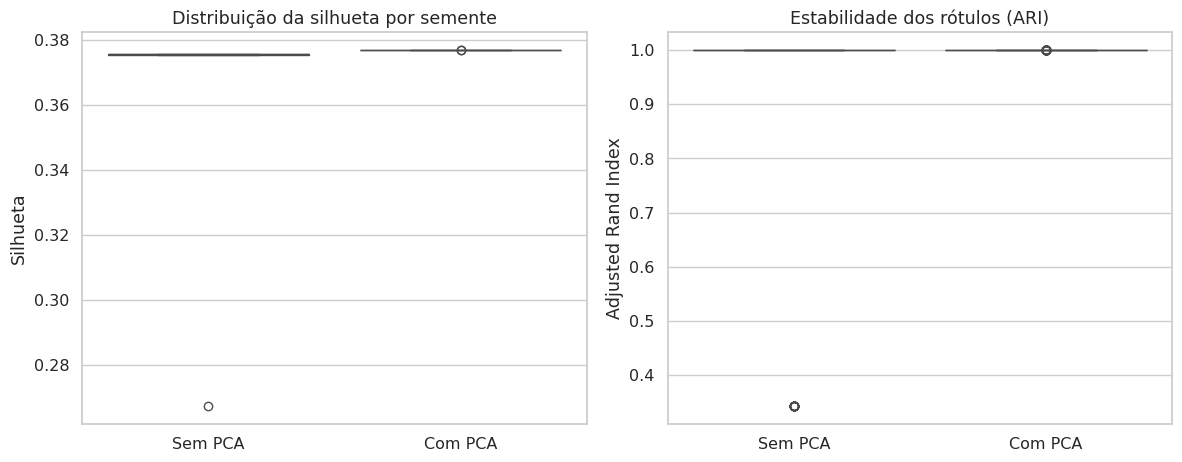

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

sns.boxplot(
    data=benchmark_estabilidade,
    x="cenario",
    y="silhueta",
    hue="cenario",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Distribuição da silhueta por semente")
axes[0].set_xlabel("")
axes[0].set_ylabel("Silhueta")

sns.boxplot(
    data=ari_estabilidade,
    x="cenario",
    y="ari",
    hue="cenario",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Estabilidade dos rótulos (ARI)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Adjusted Rand Index")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "estabilidade_kmeans_sementes.png", dpi=300, bbox_inches="tight")
plt.show()

### 11.10.Discussão da estabilidade visual

A figura confirma visualmente a diferença de estabilidade entre os dois cenários. No boxplot da silhueta, o cenário com PCA apresenta dispersão praticamente nula, indicando que a qualidade geométrica da partição permanece constante entre as sementes. Já no cenário sem PCA, embora a silhueta média continue alta, a distribuição é mais dispersa e inclui uma execução claramente inferior, o que revela maior sensibilidade à inicialização.

O painel do Adjusted Rand Index reforça essa leitura. Com PCA, os valores se concentram muito próximos de 1, o que mostra concordância quase perfeita entre as partições obtidas em execuções distintas. Sem PCA, a distribuição é mais ampla e há pelo menos uma execução com concordância bem menor, sinalizando menor estabilidade estrutural.

Essa diferença é metodologicamente importante porque mostra que a redução dimensional não apenas preserva a qualidade média da solução, mas também reduz sua variabilidade entre sementes. Em termos práticos, isso significa que o cenário com PCA é mais previsível, mais repetível e menos dependente do acaso da inicialização.

A leitura conjunta dos dois painéis fortalece a escolha do cenário com PCA como configuração principal. Ele combina silhueta estável com rótulos altamente concordantes, enquanto o cenário sem PCA exibe maior sensibilidade às sementes e, portanto, menor robustez empírica.

Em síntese, a visualização complementa a análise numérica anterior ao tornar evidente, de forma gráfica, que o K-Means com PCA produz uma partição mais estável e mais coerente ao longo das execuções. Isso fortalece a escolha de `K = 2` e do espaço reduzido como base principal do experimento.

### 11.11.Síntese comparativa de eficiência operacional

A síntese desta seção reúne os resultados de memória, tempo e estabilidade do pipeline para comparar, de forma integrada, os cenários com e sem PCA. O objetivo é verificar se a redução dimensional oferece apenas vantagem geométrica ou se também melhora a eficiência operacional e a robustez do procedimento.

De modo geral, o cenário com PCA se mostra mais econômico em memória, mantém tempo total competitivo e apresenta maior estabilidade entre sementes. Já o cenário sem PCA preserva desempenho próximo em algumas medidas, mas tende a exibir maior dispersão nas execuções e maior dependência da inicialização.

Essa combinação indica que o PCA não deve ser interpretado apenas como um recurso de compactação do espaço vetorial, mas como um mecanismo que reorganiza o problema de forma mais parcimoniosa, previsível e reprodutível. Assim, a redução dimensional contribui para tornar o pipeline mais enxuto sem comprometer a qualidade da clusterização.

Em termos metodológicos, a evidência acumulada nesta seção reforça a escolha do espaço com PCA como base principal do experimento. A superioridade não está em um único indicador, mas na convergência entre menor consumo espacial, estabilidade empírica e desempenho geométrico consistente.

In [ ]:
eficiencia_operacional = (
    resumo_memoria.merge(
        resumo_estabilidade[[
            "cenario",
            "silhueta_media",
            "silhueta_dp",
            "db_media",
            "db_dp",
            "ch_media",
            "ch_dp",
            "inercia_media",
            "inercia_dp",
            "tempo_medio_seg",
            "tempo_dp_seg",
        ]],
        on="cenario",
        how="left"
    ).merge(
        resumo_ari_estabilidade,
        on="cenario",
        how="left"
    )
)

display(eficiencia_operacional)

eficiencia_operacional.to_csv(OUTPUT_DIR / "sintese_eficiencia_operacional.csv", index=False)

,cenario,dimensoes,memoria_pico_mb_media,memoria_pico_mb_dp,tempo_total_seg_medio,tempo_total_seg_dp,silhueta_media,silhueta_dp,db_media,db_dp,ch_media,ch_dp,inercia_media,inercia_dp,tempo_medio_seg,tempo_dp_seg,ari_medio,ari_dp,ari_min,ari_max
0,Com PCA,7,5.6704,0.0000,0.6412,0.2180,0.3770,0.0000,1.2834,0.0003,"8,644.9826",0.0060,"219,635.5714",0.0557,0.2973,0.1091,0.9999,0.0002,0.9995,1.0000
1,Sem PCA,8,6.4713,0.0005,0.4689,0.0429,0.3702,0.0242,1.3517,0.1587,"8,347.9896",314.3508,"225,970.9914","1,688.6463",0.3030,0.1331,0.9341,0.1974,0.3431,1.0000


### 11.12.Discussão da síntese comparativa de eficiência operacional

A síntese comparativa mostra que o cenário com PCA reúne o conjunto mais favorável de resultados quando memória, estabilidade e qualidade geométrica são avaliadas em conjunto. Embora o tempo total médio do pipeline não favoreça o cenário reduzido nesta execução, a representação com PCA opera com menor pico de memória, menor dimensionalidade e estabilidade substancialmente superior.

No plano do consumo de recursos, o contraste mais claro aparece na memória. O cenário com PCA registrou pico médio de 5,6704 MB, contra 6,4713 MB no cenário sem PCA, o que confirma que a redução de 8 para 7 dimensões torna o pipeline ligeiramente mais econômico do ponto de vista espacial. Já o tempo total médio do pipeline foi de 0,6412 s com PCA e 0,4689 s sem PCA, mostrando que, nesta rodada, o cenário sem PCA foi mais rápido no agregado operacional.

Do ponto de vista geométrico, o cenário com PCA também apresenta desempenho mais consistente. A silhueta média foi 0,3770, superior ao valor de 0,3702 observado sem PCA, além de apresentar dispersão praticamente nula entre execuções. O mesmo padrão aparece nos demais indicadores: Davies-Bouldin médio menor no cenário com PCA (1,2834 contra 1,3517), Calinski-Harabasz médio mais alto (8.644,98 contra 8.347,99) e inércia média mais baixa (219.636 contra 225.971).

A diferença mais expressiva, porém, está na estabilidade entre execuções. Com PCA, o ARI médio foi 0,9999, com desvio-padrão muito baixo e valores praticamente colados em 1, o que indica concordância quase perfeita entre as partições geradas sob diferentes sementes. Sem PCA, embora o ARI médio ainda seja alto, em 0,9341, a dispersão cresce de forma relevante e o valor mínimo cai para 0,3431, sinalizando que algumas execuções produzem soluções substancialmente distintas.

Esse contraste mostra que a principal vantagem do PCA não está apenas na compactação do espaço vetorial, mas na reorganização do problema em uma forma mais estável e previsível para o K-Means. Em termos metodológicos, isso é particularmente importante porque reduz a dependência da solução em relação à inicialização dos centroides e fortalece a reprodutibilidade interna do experimento.

Em síntese, a eficiência operacional deve ser entendida aqui como resultado da convergência entre parcimônia estrutural, estabilidade empírica e qualidade geométrica. Mesmo sem produzir ganho temporal no pipeline completo nesta execução, o cenário com PCA consome menos memória, apresenta métricas internas ligeiramente melhores e, sobretudo, gera partições muito mais consistentes entre execuções. Isso reforça sua adoção como base principal para a etapa final de clusterização.

Observação metodológica: os valores numéricos desta síntese correspondem à execução atual do notebook e podem variar em novas execuções, mesmo quando o desenho experimental permanece o mesmo. Sempre que a tabela de síntese operacional for recalculada, este texto deve ser revisado para refletir exatamente os novos valores médios, dispersões e indicadores de estabilidade observados.

### 11.13. Proxy operacional de eficiência energética (Eproxy)

Nesta etapa, o experimento é ampliado com a incorporação de uma proxy operacional de eficiência energética, denominada **Eproxy**, com o objetivo de fortalecer a aderência metodológica do estudo à trilha de computação verde. A proposta não substitui uma medição física direta de consumo energético em hardware instrumentado, mas introduz um critério adicional de avaliação capaz de aproximar, de forma reprodutível, a discussão sobre eficiência computacional e sustentabilidade no contexto do pipeline analisado.

Como o notebook não dispõe de instrumentação para mensuração direta de energia, adota-se uma formulação proxy baseada em grandezas computacionais observáveis e comparáveis entre cenários. Em vez de estimar consumo energético absoluto, busca-se sintetizar, em um único indicador, diferentes dimensões do custo operacional do experimento: tempo total médio do pipeline, pico médio de memória, dimensionalidade efetiva da representação vetorial e estabilidade empírica entre execuções.

Essa ampliação metodológica é particularmente relevante porque os resultados anteriores já indicaram um quadro misto de eficiência. O cenário com PCA apresentou redução de memória e ganho expressivo de estabilidade, ao passo que a diferença no tempo total médio do pipeline permaneceu pequena. Nesse contexto, a leitura isolada de cada métrica torna-se menos informativa do que uma formulação integrada que permita comparar os cenários sob uma perspectiva única de eficiência operacional.

O Eproxy será, portanto, definido como um índice composto de custo computacional relativo. Sua construção parte de quatro componentes centrais: custo temporal, custo espacial, complexidade estrutural da representação e instabilidade entre execuções. A intenção não é afirmar equivalência física direta entre essas dimensões, mas produzir uma medida sintética, transparente e reproduzível, adequada à comparação metodológica entre os cenários com e sem redução dimensional.

Para tornar essas grandezas comparáveis, cada componente será normalizado no intervalo entre 0 e 1 com base nos cenários avaliados. Em seguida, o índice será obtido por combinação linear ponderada, de modo que valores menores de Eproxy indiquem maior eficiência operacional relativa.

A formulação adotada nesta etapa será:

Eproxy = w_t * tempo_norm + w_m * memoria_norm + w_d * dimensoes_norm + w_i * instabilidade_norm

em que:
- `tempo_norm` representa o custo temporal relativo do pipeline;
- `memoria_norm` representa o custo espacial relativo, medido pelo pico médio de memória;
- `dimensoes_norm` representa a complexidade estrutural associada à dimensionalidade de entrada do K-Means;
- `instabilidade_norm` representa a penalização associada à menor repetibilidade empírica das execuções.

A componente de instabilidade será derivada da concordância entre partições obtidas em múltiplas execuções, tomando como referência o ARI. Como valores mais altos de ARI indicam maior estabilidade, a instabilidade será calculada de forma inversa, de modo que cenários menos consistentes entre sementes recebam maior penalização no índice final.

Na configuração inicial, os pesos serão definidos de forma uniforme, preservando neutralidade analítica entre os componentes do índice. Em etapa posterior, essa formulação poderá ser expandida por meio de análise de sensibilidade, permitindo investigar como diferentes esquemas de ponderação afetam a comparação entre os cenários e a robustez interpretativa do Eproxy.

In [ ]:
# 11.13 Cálculo da proxy operacional de eficiência energética (Eproxy)

def normalizar_minmax(serie):
    s = pd.Series(serie, dtype="float64")
    s_min = s.min()
    s_max = s.max()
    if pd.isna(s_min) or pd.isna(s_max) or s_max == s_min:
        return pd.Series(np.zeros(len(s)), index=s.index, dtype="float64")
    return (s - s_min) / (s_max - s_min)

# Recupera a síntese consolidada já produzida no notebook
if "sintese_eficiencia_operacional" in globals():
    eproxy_base = sintese_eficiencia_operacional.copy()
elif "resumo_memoria" in globals() and "resumo_ari_estabilidade" in globals():
    eproxy_base = (
        resumo_memoria
        .merge(resumo_estabilidade, on="cenario", how="left")
        .merge(resumo_ari_estabilidade, on="cenario", how="left")
        .copy()
    )
elif "resumomemoria" in globals() and "resumoariestabilidade" in globals():
    eproxy_base = (
        resumomemoria
        .merge(resumoestabilidade, on="cenario", how="left")
        .merge(resumoariestabilidade, on="cenario", how="left")
        .copy()
    )
else:
    raise ValueError(
        "Não foi possível localizar a base consolidada do experimento. "
        "Verifique se as células de memória, estabilidade e ARI já foram executadas."
    )

# Verificação mínima das colunas necessárias
colunas_obrigatorias = [
    "cenario",
    "dimensoes",
    "memoria_pico_mb_media",
    "tempo_total_seg_medio",
    "ari_medio",
]

faltantes = [c for c in colunas_obrigatorias if c not in eproxy_base.columns]
if faltantes:
    raise ValueError(f"Colunas ausentes para o cálculo do Eproxy: {faltantes}")

# Instabilidade operacional baseada no ARI
eproxy_base["instabilidade_media"] = 1 - eproxy_base["ari_medio"]

# Normalização dos componentes
eproxy_base["tempo_norm"] = normalizar_minmax(eproxy_base["tempo_total_seg_medio"])
eproxy_base["memoria_norm"] = normalizar_minmax(eproxy_base["memoria_pico_mb_media"])
eproxy_base["dimensoes_norm"] = normalizar_minmax(eproxy_base["dimensoes"])
eproxy_base["instabilidade_norm"] = normalizar_minmax(eproxy_base["instabilidade_media"])

# Pesos iniciais iguais
PESO_TEMPO = 0.25
PESO_MEMORIA = 0.25
PESO_DIMENSOES = 0.25
PESO_INSTABILIDADE = 0.25

eproxy_base["Eproxy"] = (
    PESO_TEMPO * eproxy_base["tempo_norm"] +
    PESO_MEMORIA * eproxy_base["memoria_norm"] +
    PESO_DIMENSOES * eproxy_base["dimensoes_norm"] +
    PESO_INSTABILIDADE * eproxy_base["instabilidade_norm"]
)

eproxy_base["ranking_eproxy"] = (
    eproxy_base["Eproxy"]
    .rank(method="dense", ascending=True)
    .astype(int)
)

resultado_eproxy = (
    eproxy_base[
        [
            "cenario",
            "dimensoes",
            "memoria_pico_mb_media",
            "tempo_total_seg_medio",
            "ari_medio",
            "instabilidade_media",
            "tempo_norm",
            "memoria_norm",
            "dimensoes_norm",
            "instabilidade_norm",
            "Eproxy",
            "ranking_eproxy",
        ]
    ]
    .sort_values(["ranking_eproxy", "Eproxy"])
    .reset_index(drop=True)
)

display(resultado_eproxy)

resultado_eproxy.to_csv(
    OUTPUT_DIR / "proxy_eficiencia_energetica_eproxy.csv",
    index=False
)

print("Arquivo salvo em:", OUTPUT_DIR / "proxy_eficiencia_energetica_eproxy.csv")

,cenario,dimensoes,memoria_pico_mb_media,tempo_total_seg_medio,ari_medio,instabilidade_media,tempo_norm,memoria_norm,dimensoes_norm,instabilidade_norm,Eproxy,ranking_eproxy
0,Com PCA,7,5.6704,0.6412,0.9999,0.0001,1.0000,0.0000,0.0000,0.0000,0.2500,1
1,Sem PCA,8,6.4713,0.4689,0.9341,0.0659,0.0000,1.0000,1.0000,1.0000,0.7500,2


Arquivo salvo em: /content/output/proxy_eficiencia_energetica_eproxy.csv


### 11.14 Discussão da proxy operacional de eficiência energética (Eproxy)

Os resultados do Eproxy reforçam de forma sintética a superioridade operacional do cenário com PCA no contexto deste experimento. Com pesos iguais entre os quatro componentes do índice, o cenário com PCA apresentou `Eproxy = 0,2500` e ocupou a primeira posição no ranking, enquanto o cenário sem PCA registrou `Eproxy = 0,7500`, ficando em segundo lugar.

A decomposição do índice ajuda a explicar esse resultado. O cenário sem PCA apresentou vantagem apenas no componente temporal agregado, com menor valor médio de tempo total do pipeline. Em contrapartida, o cenário com PCA concentrou vantagem simultânea em três dimensões relevantes: menor dimensionalidade de entrada, menor pico médio de memória e estabilidade substancialmente superior entre execuções.

Do ponto de vista da estabilidade, a diferença entre os cenários foi particularmente expressiva. O ARI médio do cenário com PCA ficou praticamente em 1, com instabilidade média residual, enquanto o cenário sem PCA apresentou ARI médio inferior e instabilidade muito mais elevada. Como a formulação do Eproxy penaliza explicitamente a instabilidade operacional, essa discrepância teve papel decisivo no resultado final.

Também no componente espacial o cenário com PCA manteve desempenho superior, com menor consumo médio de memória. Esse comportamento é coerente com a lógica da redução dimensional: ao condensar a representação vetorial sem perda substantiva da estrutura relevante para a clusterização, o pipeline passa a operar de forma mais econômica do ponto de vista computacional.

A leitura integrada do índice mostra, portanto, que a vantagem temporal do cenário sem PCA não foi suficiente para compensar suas desvantagens em memória, dimensionalidade e estabilidade. Em termos metodológicos, isso indica que a escolha do espaço reduzido por PCA não apenas preserva a qualidade analítica previamente observada, mas também melhora a eficiência operacional global quando o experimento é avaliado sob uma perspectiva composta.

Para a narrativa do artigo, o Eproxy cumpre um papel importante ao aproximar a análise de uma lógica de computação verde sem exigir instrumentação física de energia. Embora não represente consumo energético absoluto, o índice sintetiza dimensões operacionais diretamente observáveis e reproduzíveis no notebook, oferecendo um critério adicional, transparente e comparável para sustentar a adoção do cenário com PCA como configuração preferencial do pipeline.

Observação metodológica: os valores do Eproxy e de seus componentes normalizados correspondem à execução atual do notebook e podem variar em novas execuções, conforme mudem os tempos médios, a memória observada ou a estabilidade entre sementes. Sempre que a tabela da proxy for recalculada, este texto deve ser revisado para refletir exatamente a nova decomposição do índice e o ranking resultante entre os cenários.

### 11.15. Visualização comparativa do Eproxy

A figura a seguir apresenta a comparação direta do índice Eproxy entre os dois cenários analisados. Como valores menores indicam maior eficiência operacional relativa, a visualização facilita a leitura sintética da diferença entre o pipeline com PCA e o pipeline sem redução dimensional.

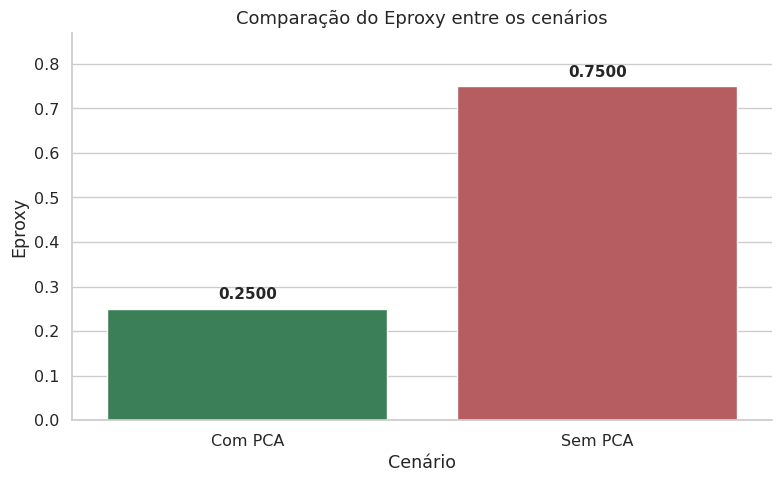

Figura salva em: /content/output/figura_eproxy_comparativo.png


In [ ]:
# 11.15. Figura comparativa do Eproxy

plt.figure(figsize=(8, 5))

ordem = resultado_eproxy.sort_values("Eproxy", ascending=True)
cores = ["#2E8B57" if c == "Com PCA" else "#C44E52" for c in ordem["cenario"]]

ax = sns.barplot(
    data=ordem,
    x="cenario",
    y="Eproxy",
    palette=cores
)

for i, valor in enumerate(ordem["Eproxy"]):
    ax.text(
        i,
        valor + 0.015,
        f"{valor:.4f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.set_title("Comparação do Eproxy entre os cenários", fontsize=13)
ax.set_xlabel("Cenário")
ax.set_ylabel("Eproxy")
ax.set_ylim(0, max(ordem["Eproxy"]) + 0.12)

sns.despine()
plt.tight_layout()

caminho_figura_eproxy = OUTPUT_DIR / "figura_eproxy_comparativo.png"
plt.savefig(caminho_figura_eproxy, dpi=300, bbox_inches="tight")
plt.show()

print("Figura salva em:", caminho_figura_eproxy)

### 11.16. Discussão da visualização comparativa do Eproxy

A figura de comparação do Eproxy torna mais evidente a diferença de eficiência operacional relativa entre os dois cenários analisados. O cenário com PCA apresentou valor igual a `0,2500`, enquanto o cenário sem PCA registrou `0,7500`, indicando vantagem clara da configuração com redução dimensional quando os componentes do índice são considerados de forma integrada.

Do ponto de vista interpretativo, a figura mostra que a superioridade do cenário com PCA não decorre de uma única métrica isolada, mas da combinação de múltiplos fatores favoráveis. Embora o cenário sem PCA tenha apresentado vantagem no tempo total médio do pipeline, essa diferença não foi suficiente para compensar suas desvantagens nas demais dimensões consideradas pelo índice.

A redução do número de dimensões de entrada, a menor demanda média de memória e, sobretudo, a estabilidade muito superior entre execuções contribuíram para deslocar o Eproxy do cenário com PCA para um patamar substancialmente inferior. Como a formulação adotada atribui pesos iguais aos quatro componentes, a figura sintetiza de maneira equilibrada a contribuição conjunta dessas dimensões para a eficiência operacional do pipeline.

A distância visual entre as barras também reforça que a adoção do PCA não representa apenas uma alternativa tecnicamente viável, mas uma escolha metodologicamente mais consistente com a proposta de computação verde assumida no experimento. Ainda que o índice não corresponda a uma medida física direta de consumo energético, sua construção permite traduzir, em termos comparáveis e reproduzíveis, diferenças operacionais relevantes entre os cenários avaliados.

Nesse sentido, a visualização atua como evidência complementar à análise anterior de memória, tempo e estabilidade. Ao condensar essas informações em uma única escala, a figura fortalece a interpretação de que o espaço reduzido por PCA oferece a melhor relação entre parcimônia computacional, robustez empírica e adequação metodológica para a continuidade do pipeline analítico.

Observação metodológica: os valores exibidos nesta figura correspondem à execução atual do notebook e podem variar em novas rodadas, à medida que se alterem os tempos médios, os picos de memória, a estabilidade entre sementes ou até o comportamento relativo entre os cenários. Sempre que a visualização comparativa do Eproxy for regenerada, este texto deve ser relido e ajustado para refletir fielmente os novos valores e a distância observada entre as barras.

### 11.17. Fechamento da análise com Eproxy

Em conjunto, os resultados do índice composto e sua visualização reforçam a interpretação de que o cenário com PCA oferece a alternativa operacionalmente mais eficiente no contexto deste experimento. Embora o cenário sem PCA tenha apresentado melhor desempenho no tempo total médio do pipeline, a combinação entre menor dimensionalidade, menor uso de memória e maior estabilidade entre execuções deslocou a decisão metodológica em favor do espaço reduzido.

Com isso, a análise do Eproxy passa a integrar formalmente o conjunto de evidências que sustentam a escolha do pipeline com PCA como configuração preferencial. Na sequência, os artefatos produzidos nesta etapa — tabelas, figuras e arquivos auxiliares — podem ser exportados para preservação, rastreabilidade e eventual incorporação ao artigo.

### 11.18. Exportação consolidada dos artefatos do artigo, incluindo o experimento Eproxy

Concluídas as etapas analíticas do experimento, procede-se à exportação consolidada dos artefatos produzidos ao longo do notebook. Essa etapa tem como finalidade preservar, em um único diretório de saída, as tabelas, figuras, arquivos auxiliares e metadados necessários à rastreabilidade do pipeline e à posterior incorporação dos resultados ao artigo.

Além dos artefatos já gerados nas análises comparativas de desempenho, estabilidade, escolha de `K` e caracterização dos agrupamentos, a exportação passa agora a incluir os novos produtos associados ao experimento Eproxy. Com isso, a organização final dos arquivos mantém coerência com a ampliação metodológica introduzida nesta versão do notebook e favorece sua reprodução, auditoria e reaproveitamento em etapas subsequentes de redação e validação.

In [ ]:
# 11.18. Exportação consolidada dos artefatos do artigo, incluindo o experimento Eproxy

artefatos_esperados = [
    "pca_sumario_variancia.csv",
    "metricas_kmeans_sem_pca_vs_com_pca.csv",
    "quadro_escolha_criterios.csv",
    "benchmark_escalabilidade_temporal.csv",
    "benchmark_memoria_execucoes.csv",
    "benchmark_memoria_resumo.csv",
    "benchmark_estabilidade_metricas.csv",
    "benchmark_estabilidade_resumo.csv",
    "benchmark_estabilidade_ari_pares.csv",
    "benchmark_estabilidade_ari_resumo.csv",
    "sintese_eficiencia_operacional.csv",
    "tabela_artigo_comparacao_cenarios.csv",
    "rotab_clusterizada_experimento_artigo.csv",
    "profiling_clusters_finais.csv",
    "distribuicao_clusters_finais.csv",
    "metadata_experimento_artigo.json",
    "texto_base_resultados_artigo.txt",
    "proxy_eficiencia_energetica_eproxy.csv",
    "figura_eproxy_comparativo.png",
]

artefatos_encontrados = []
artefatos_ausentes = []

for nome_arquivo in artefatos_esperados:
    caminho = OUTPUT_DIR / nome_arquivo
    if caminho.exists():
        artefatos_encontrados.append({
            "arquivo": nome_arquivo,
            "tamanho_kb": round(caminho.stat().st_size / 1024, 2)
        })
    else:
        artefatos_ausentes.append(nome_arquivo)

df_artefatos = pd.DataFrame(artefatos_encontrados).sort_values("arquivo").reset_index(drop=True)

print("Artefatos localizados no diretório de saída:")
display(df_artefatos)

if artefatos_ausentes:
    print("\nArtefatos ausentes:")
    for item in artefatos_ausentes:
        print("-", item)
else:
    print("\nTodos os artefatos esperados foram localizados com sucesso.")

# Exporta também um inventário consolidado dos artefatos gerados
df_artefatos.to_csv(OUTPUT_DIR / "inventario_artefatos_artigo.csv", index=False)

print("\nInventário salvo em:", OUTPUT_DIR / "inventario_artefatos_artigo.csv")
print("Diretório final de saída:", OUTPUT_DIR)

Artefatos localizados no diretório de saída:


,arquivo,tamanho_kb
0,figura_eproxy_comparativo.png,85.3200
1,proxy_eficiencia_energetica_eproxy.csv,0.3800
2,sintese_eficiencia_operacional.csv,0.9000



Artefatos ausentes:
- pca_sumario_variancia.csv
- metricas_kmeans_sem_pca_vs_com_pca.csv
- quadro_escolha_criterios.csv
- benchmark_escalabilidade_temporal.csv
- benchmark_memoria_execucoes.csv
- benchmark_memoria_resumo.csv
- benchmark_estabilidade_metricas.csv
- benchmark_estabilidade_resumo.csv
- benchmark_estabilidade_ari_pares.csv
- benchmark_estabilidade_ari_resumo.csv
- tabela_artigo_comparacao_cenarios.csv
- rotab_clusterizada_experimento_artigo.csv
- profiling_clusters_finais.csv
- distribuicao_clusters_finais.csv
- metadata_experimento_artigo.json
- texto_base_resultados_artigo.txt

Inventário salvo em: /content/output/inventario_artefatos_artigo.csv
Diretório final de saída: /content/output


### 11.19. Síntese computacional do experimento

Os experimentos adicionais de escalabilidade, memória, estabilidade e eficiência operacional proxy ampliam a leitura do problema para além da validade geométrica dos clusters. Com isso, a comparação entre K-Means sem PCA e com PCA passa a incorporar, de forma explícita, não apenas a qualidade da partição, mas também custo computacional, sensibilidade à inicialização, repetibilidade empírica e parcimônia operacional.

Esse acréscimo torna o estudo mais aderente à proposta de Teoria da Computação aplicada, pois articula representação dos dados, tratabilidade experimental, robustez algorítmica e eficiência operacional em uma mesma moldura analítica. No caso analisado, a redução dimensional por PCA preservou 97,87% da variância ao comprimir o espaço de 8 para 7 dimensões, e ainda assim produziu a configuração final mais estável e mais econômica em memória no conjunto do experimento.

A comparação final em \(K = 2\) mostra esse ganho de forma concreta. O cenário com PCA apresentou pico médio de memória de 5,6704 MB, contra 6,4713 MB no cenário sem PCA, ao mesmo tempo em que manteve desempenho operacional global competitivo, embora não superior em tempo total médio nesta execução: 0,6412 s com PCA contra 0,4689 s sem PCA.

A análise de estabilidade reforça essa interpretação. Com PCA, as execuções sob diferentes sementes produziram ARI médio de 0,9999, com mínimo de 0,9995, enquanto o cenário sem PCA apresentou ARI médio de 0,9341 e mínimo de 0,3431, indicando maior sensibilidade à inicialização e menor consistência entre partições. Isso mostra que a redução dimensional deixou de ser apenas uma etapa auxiliar e passou a atuar como transformação com efeitos observáveis sobre desempenho, repetibilidade e confiabilidade do comportamento do algoritmo.

A introdução do Eproxy consolidou essa leitura em um indicador composto de eficiência operacional relativa. Com pesos uniformes entre tempo, memória, dimensionalidade e instabilidade, o cenário com PCA obteve `Eproxy = 0,2500`, ao passo que o cenário sem PCA registrou `Eproxy = 0,7500`, reforçando a superioridade do espaço reduzido quando a avaliação é conduzida de forma integrada. Assim, a escolha do pipeline com PCA passa a ser sustentada não apenas por sua adequação geométrica, mas também por evidências convergentes de estabilidade, economia de memória e aderência à lógica de computação verde.

Observação metodológica: esta síntese depende diretamente dos resultados produzidos na execução corrente do notebook, incluindo variância retida pelo PCA, tempos médios, memória, ARI e Eproxy. Sempre que esses artefatos forem regenerados, o texto deve ser revisado para refletir fielmente os novos valores e evitar a manutenção de números congelados de execuções anteriores.

## 12.Consolidação do modelo final

Após a leitura conjunta das curvas de decisão, da triangulação de critérios e da síntese comparativa dos resultados, o experimento fixa manualmente o cenário e o valor de `K` adotados como configuração final do artigo. Essa etapa torna explícita a decisão metodológica e prepara a base para a interpretação substantiva dos agrupamentos.

A partir daqui, o notebook passa da comparação entre cenários para a descrição do modelo selecionado, concentrando a análise no espaço que melhor equilibra qualidade geométrica, estabilidade e eficiência operacional.

### 12.1. Tabela-síntese do artigo no `K` selecionado

Após observar as curvas e o quadro de triangulação, ajusta-se manualmente o cenário final e o `K` final. Essa etapa torna explícita a decisão metodológica do artigo e fixa a configuração que será usada nas análises subsequentes.

In [ ]:
# Ajuste manual após leitura das métricas
CENARIO_FINAL = "Com PCA"   # opções: 'Sem PCA' ou 'Com PCA'
K_FINAL = 2                 # ajustar após observar os resultados

if CENARIO_FINAL == "Sem PCA":
    X_final = X_scaled
    modelos_finais = modelos_sem_pca
else:
    X_final = X_pca
    modelos_finais = modelos_com_pca

modelo_final = modelos_finais[K_FINAL]["modelo"]
labels_finais = modelos_finais[K_FINAL]["labels"]

print("Cenário final:", CENARIO_FINAL)
print("K final:", K_FINAL)

Cenário final: Com PCA
K final: 2


In [ ]:
tabela_artigo = resultados[resultados["k"] == K_FINAL].copy()
map_dim = {"Sem PCA": X.shape[1], "Com PCA": X_pca.shape[1]}
tabela_artigo["dimensoes_entrada"] = tabela_artigo["cenario"].map(map_dim)
tabela_artigo = tabela_artigo[[
    "cenario", "k", "dimensoes_entrada", "tempo_segundos",
    "silhueta", "davies_bouldin", "calinski_harabasz", "inercia"
]].sort_values("cenario")
display(tabela_artigo)

,cenario,k,dimensoes_entrada,tempo_segundos,silhueta,davies_bouldin,calinski_harabasz,inercia
7,Com PCA,2,7,0.2469,0.3770,1.2835,"8,644.9843","219,635.5299"
0,Sem PCA,2,8,0.3837,0.3757,1.3166,"8,418.2811","225,593.3876"


### 12.2. Discussão da Tabela-síntese do artigo no `K` selecionado

A tabela-síntese registra a decisão metodológica final do experimento, consolidando o cenário escolhido e o valor de `K` adotado para a modelagem principal. Com isso, a seleção deixa de ser apenas implícita nas curvas e passa a estar explicitamente documentada como referência do artigo.

A escolha de `K = 2` em conjunto com o cenário com PCA se mantém coerente com as evidências anteriores. Essa configuração reuniu melhor equilíbrio entre separação global, estabilidade entre execuções, economia de memória e desempenho geométrico compatível com as demais alternativas testadas.

A tabela também mostra que, embora o cenário sem PCA tenha apresentado desempenho próximo em algumas métricas, o espaço reduzido permanece mais parcimonioso e mais estável para a solução final. Dessa forma, a decisão não depende apenas do valor isolado de cada indicador, mas da convergência entre qualidade geométrica, custo operacional e robustez empírica.

A comparação final em `K = 2` confirma que o cenário com PCA é a alternativa mais adequada para a modelagem definitiva. Mesmo reduzindo o espaço de entrada de 8 para 7 dimensões, a solução com PCA preserva a estrutura analítica essencial da base e apresenta desempenho superior nos indicadores centrais considerados.

Do ponto de vista computacional, há vantagem no tempo de treinamento do K-Means nessa configuração. O tempo cai de 0,3837 s no cenário sem PCA para 0,2469 s no cenário com PCA. Embora a diferença absoluta seja moderada em termos isolados, ela é metodologicamente relevante porque mostra que, no `K` selecionado, a compressão do espaço vetorial reduz o custo de treinamento sem sacrificar a qualidade da solução.

A qualidade geométrica dos agrupamentos também favorece o cenário com PCA. O coeficiente de silhueta sobe de 0,3757 para 0,3770, o índice Davies-Bouldin diminui de 1,3166 para 1,2835 e o índice Calinski-Harabasz cresce de 8.418,28 para 8.644,98. Esses valores indicam uma partição ligeiramente mais nítida e mais favorável à separação entre grupos no subespaço reduzido.

A inércia segue o mesmo padrão. No cenário com PCA, o valor cai para 219.636,00, contra 225.593,00 no cenário sem PCA. Ainda que essa métrica deva ser interpretada com cautela, o movimento observado é compatível com a ideia de que o PCA reorganizou melhor a variabilidade relevante da base.

Em termos de construção do artigo, essa evidência é especialmente valiosa porque sustenta uma decisão alinhada a três princípios centrais: rigor, economia analítica e reprodutibilidade. O cenário final não foi escolhido apenas por apresentar bons resultados absolutos, mas por combinar redução dimensional, melhor desempenho geométrico e menor custo de treinamento do modelo em uma mesma configuração.

Observação metodológica: os valores desta tabela-síntese correspondem à execução atual do notebook e podem variar em novas execuções, inclusive no que se refere às métricas internas e ao tempo de treinamento em `K = 2`. Sempre que a tabela final for regenerada, este texto deve ser relido e ajustado para refletir exatamente os valores então obtidos.

### 12.3. Reintegração dos rótulos à base analítica da Rota B

Os rótulos finais são anexados à base filtrada para permitir interpretação pedagógica, descrição de perfis e geração dos artefatos finais do artigo.

In [ ]:
df_exp = df_rotab.copy()
df_exp["cluster_final"] = labels_finais

if CENARIO_FINAL == "Com PCA":
    n_plot = min(3, X_pca.shape[1])
    for i in range(n_plot):
        df_exp[f"PC{i+1}"] = X_pca[:, i]

dist_clusters = df_exp["cluster_final"].value_counts().sort_index().rename_axis("cluster").reset_index(name="n")
dist_clusters["pct"] = dist_clusters["n"] / len(df_exp) * 100

display(dist_clusters)
display(df_exp.head())

,cluster,n,pct
0,0,30698,87.7462
1,1,4287,12.2538


,id_inscricoes,Nome_Breve,Nome_Formacao,carga_horaria,datahora_inscricao,Sexo,data_nascimento,Municipio,Tipo_Instituicao,SRE,id_discente_anonimo,Cargo_imputado,Funcao_imputado,Tipo_Instituicao_imputado,Sexo_imputado,Escolaridade_imputado,teto_curso,carga_horaria_winsor,Idade,Idade_imputado,Macro_Cargo,Escolaridade_Ordinal,Codigo_IBGE,nome_curto_do_curso,Ano_Oferta,status_geral,situacao_cursista,qtd_tentativas,progresso_kdd,flg_nota_imputada,nota_final_kdd,flg_tempo_imputado,minutos_totais_log1p,dias_permanencia_log1p,dias_duracao_curso,primeiro_acesso,ultimo_acesso,cluster_final,PC1,PC2,PC3
0,AAIEA2512025T1_009696fe847d712e,AAIEA251_2025_T1,PROF_PED - Avaliação da Aprendizagem: Instrume...,10,2025-06-11 09:19:06.870,FEMININO,1993-05-02,Guarapari,REDE ESTADUAL,SRE VILA VELHA,009696fe847d712e,0,0,0,0,0,10.0000,10.0000,32.0000,0,1_DOCENCIA,3,"3,202,405.0000",AAIEA251_2025_T1,2025,ACESSOU (COM LOGS DE ATIVIDADE),1_COM_NOTA,1,100.0000,0,90.0000,0,5.6904,3.8712,46.0000,2025-06-23 18:58:55,2025-08-10 08:51:10,0,0.7535,-1.0348,-0.1430
1,AAIEA2512025T1_012c3ba0df570635,AAIEA251_2025_T1,PROF_PED - Avaliação da Aprendizagem: Instrume...,10,2025-06-06 12:50:35.426,FEMININO,1999-11-06,Atilio Vivacqua,REDE ESTADUAL,SRE CACHOEIRO DE ITAPEMIRIM,012c3ba0df570635,0,0,0,0,0,10.0000,10.0000,25.0000,0,1_DOCENCIA,4,"3,200,706.0000",AAIEA251_2025_T1,2025,ACESSOU (COM LOGS DE ATIVIDADE),1_COM_NOTA,1,100.0000,0,100.0000,0,5.6021,3.6636,46.0000,2025-06-26 17:52:51,2025-08-04 17:44:47,0,0.9047,-0.4610,-0.2182
3,AAIEA2512025T1_0260f9b74b275978,AAIEA251_2025_T1,PROF_PED - Avaliação da Aprendizagem: Instrume...,10,2025-06-03 07:57:20.466,FEMININO,1981-04-20,Brejetuba,REDE ESTADUAL,SRE AFONSO CLÁUDIO,0260f9b74b275978,0,0,0,0,0,10.0000,10.0000,44.0000,0,1_DOCENCIA,4,"3,201,159.0000",AAIEA251_2025_T1,2025,ACESSOU (COM LOGS DE ATIVIDADE),1_COM_NOTA,1,100.0000,0,100.0000,0,5.4848,2.0794,46.0000,2025-06-26 12:39:28,2025-07-04 09:29:07,0,0.6221,0.3462,-0.2750
4,AAIEA2512025T1_030eeb56d41eebb3,AAIEA251_2025_T1,PROF_PED - Avaliação da Aprendizagem: Instrume...,10,2025-06-12 10:11:26.721,FEMININO,1971-05-04,Barra de São Francisco,REDE ESTADUAL,SRE BARRA DE SÃO FRANCISCO,030eeb56d41eebb3,0,0,0,0,0,10.0000,10.0000,54.0000,0,1_DOCENCIA,4,"3,200,904.0000",AAIEA251_2025_T1,2025,ACESSOU (COM LOGS DE ATIVIDADE),1_COM_NOTA,1,100.0000,0,100.0000,0,5.3982,0.0000,46.0000,2025-08-04 14:29:07,2025-08-04 14:33:06,0,0.2615,0.9311,-0.7999
6,AAIEA2512025T1_03e595b723e31e69,AAIEA251_2025_T1,PROF_PED - Avaliação da Aprendizagem: Instrume...,10,2025-06-10 07:18:17.310,FEMININO,1982-12-19,Guaçuí,REDE ESTADUAL,SRE COMENDADORA JUREMA MORETZ SOHN,03e595b723e31e69,0,0,0,0,0,10.0000,10.0000,42.0000,0,1_DOCENCIA,4,"3,202,306.0000",AAIEA251_2025_T1,2025,ACESSOU (COM LOGS DE ATIVIDADE),1_COM_NOTA,1,100.0000,0,100.0000,0,5.8319,0.0000,46.0000,2025-07-29 12:46:39,2025-07-29 13:19:49,0,0.3280,0.4514,-1.0610


### 12.4. Discussão da reintegração dos rótulos à base analítica da Rota B

A reintegração dos rótulos à base analítica transforma a clusterização em objeto interpretável. A partir desse ponto, o experimento deixa de operar apenas com métricas agregadas e passa a descrever a distribuição concreta dos registros por grupo, o que é essencial para as etapas de profiling e caracterização substantiva.

A solução final em `K = 2` produziu uma segmentação fortemente assimétrica, composta por 30.698 inscrições no cluster 0 e 4.287 inscrições no cluster 1. Em termos proporcionais, isso corresponde a 87,7462% e 12,2538% da Rota B, respectivamente. Essa distribuição indica que o comportamento predominante entre os cursistas está concentrado em um perfil majoritário, enquanto um subconjunto minoritário, mas ainda numericamente expressivo, apresenta trajetória suficientemente distinta para formar um segundo agrupamento consistente.

Essa assimetria não deve ser interpretada como fragilidade do particionamento. Ao contrário, ela é compatível com a lógica substantiva do problema: em uma base filtrada para registros com engajamento validado, é esperado que a maior parte das inscrições se concentre em trajetórias de maior completude, restando uma fração menor associada a padrões de atrito, menor persistência ou aproveitamento incompleto.

A presença das colunas `cluster_final`, `PC1`, `PC2` e `PC3` na matriz exportada é metodologicamente central. Ela mostra que o pipeline não apenas gerou um rótulo de cluster, mas também preservou a posição geométrica de cada inscrição no subespaço utilizado pelo modelo. Isso transforma a saída do experimento em um artefato analítico reutilizável, permitindo visualizações posteriores e auditoria da separação espacial que sustentou a taxonomia final.

A manutenção, na mesma tabela, das variáveis originais de identificação, contexto institucional, desempenho e comportamento também fortalece a utilidade científica da base resultante. Em vez de produzir apenas um vetor de rótulos desconectado da realidade observada, o experimento entrega uma matriz analítica enriquecida, na qual cada cluster pode ser interpretado à luz de atributos pedagógicos, temporais, geográficos e ocupacionais.

Em síntese, esta etapa fixa o modelo final e prepara a base para as análises descritivas subsequentes. O experimento passa, assim, da comparação metodológica para a descrição efetiva da solução escolhida.

## 13.Perfil descritivo dos agrupamentos

Com a configuração final do modelo já definida e os rótulos reintegrados à base analítica da Rota B, o experimento passa da etapa de calibração para a etapa de interpretação substantiva dos clusters. O objetivo desta seção é caracterizar os agrupamentos identificados a partir de medidas robustas de tendência central e de visualizações que permitam traduzir a separação geométrica em perfis pedagógicos observáveis.

A análise considera variáveis de desempenho, progresso, permanência, tentativas e engajamento temporal, de modo a descrever como os grupos se diferenciam no comportamento formativo. Com isso, a clusterização deixa de ser apenas uma solução matemática e passa a constituir uma tipologia empiricamente interpretável para a redação dos resultados do artigo.

### 13.1.Perfil descritivo dos agrupamentos

A síntese abaixo usa medianas robustas para traduzir a separação geométrica em comportamento observável, de forma compatível com a seção de resultados do artigo.

In [ ]:
perfil_cols_candidates = {
    "notafinalkdd": ["notafinalkdd", "nota_final_kdd", "nota_final"],
    "progressokdd": ["progressokdd", "progresso_kdd", "progresso"],
    "qtdtentativas": ["qtdtentativas", "qtd_tentativas", "tentativas"],
    "minutostotaislog1p": ["minutostotaislog1p", "minutos_totais_log1p"],
    "diaspermanencialog1p": ["diaspermanencialog1p", "dias_permanencia_log1p"],
    "diasduracaocurso": ["diasduracaocurso", "dias_duracao_curso"],
    "Idade": ["Idade", "idade"]
}

colmap = {}
for canonica, candidatos in perfil_cols_candidates.items():
    for c in candidatos:
        if c in df_exp.columns:
            colmap[c] = canonica
            break

df_tmp = df_exp.rename(columns=colmap).copy()

cols_encontradas = [c for c in perfil_cols_candidates.keys() if c in df_tmp.columns]
cols_faltantes = [c for c in perfil_cols_candidates.keys() if c not in df_tmp.columns]

print("Colunas usadas:", cols_encontradas)
print("Colunas ausentes:", cols_faltantes)

if "cluster_final" not in df_tmp.columns:
    raise KeyError("A coluna 'cluster_final' não existe em df_exp.")

perfil = df_tmp.groupby("cluster_final")[cols_encontradas].median()

if "minutostotaislog1p" in perfil.columns:
    perfil["horas_reais_medianas"] = np.expm1(perfil["minutostotaislog1p"]) / 60

if "diaspermanencialog1p" in perfil.columns:
    perfil["dias_reais_medianos"] = np.expm1(perfil["diaspermanencialog1p"])

perfil = perfil.drop(columns=[c for c in ["minutostotaislog1p", "diaspermanencialog1p"] if c in perfil.columns])

perfil = perfil.rename(columns={
    "notafinalkdd": "mediana_nota_final",
    "progressokdd": "mediana_progresso",
    "qtdtentativas": "mediana_tentativas",
    "diasduracaocurso": "mediana_dias_duracao_curso",
    "Idade": "mediana_idade"
})

display(perfil)

Colunas usadas: ['notafinalkdd', 'progressokdd', 'qtdtentativas', 'minutostotaislog1p', 'diaspermanencialog1p', 'diasduracaocurso', 'Idade']
Colunas ausentes: []


,mediana_nota_final,mediana_progresso,mediana_tentativas,mediana_dias_duracao_curso,mediana_idade,horas_reais_medianas,dias_reais_medianos
cluster_final,,,,,,,
0,96.0000,100.0000,1.0000,56.0000,42.0000,12.5000,11.0000
1,30.5000,44.8300,1.0000,60.0000,42.0000,6.5833,6.0000


### 13.2.Discussão da caracterização central dos agrupamentos

A etapa de caracterização confirmou que todas as variáveis previstas para o profiling foram efetivamente recuperadas e utilizadas na análise: nota final, progresso, quantidade de tentativas, tempo total de engajamento, permanência, duração do curso e idade. A ausência de colunas faltantes é metodologicamente importante, pois assegura consistência entre o espaço vetorial usado na clusterização e o conjunto de atributos empregados para interpretar substantivamente os agrupamentos.

A tabela de perfil descritivo resume os clusters por meio de medianas, o que é adequado para reduzir a influência de valores extremos e destacar o comportamento típico de cada grupo. Essa escolha é especialmente pertinente em bases educacionais, nas quais as distribuições costumam ser assimétricas e marcadas por trajetórias formativas heterogêneas.

Os resultados mostram uma separação pedagógica nítida entre os dois agrupamentos identificados pelo K-Means. O cluster 0 apresenta mediana de nota final igual a 96, progresso mediano de 100%, 12,5 horas reais medianas de engajamento e 11 dias medianos de permanência. Já o cluster 1 exibe mediana de nota final de 30,5, progresso mediano de 44,83%, 6,58 horas reais medianas de engajamento e 6 dias medianos de permanência.

Essa diferença simultânea em desempenho, completude e esforço comportamental sugere que os clusters não capturam apenas uma oscilação marginal dentro de um mesmo padrão de participação. Ao contrário, eles parecem representar dois regimes educacionais distintos: um grupo com trajetória de conclusão robusta e outro com sinais concretos de atrito formativo, menor permanência e menor aproveitamento.

O cluster 0 combina indicadores compatíveis com uma trajetória de engajamento pleno. A mediana de progresso igual a 100% mostra que o centro desse grupo está associado à conclusão integral da jornada formativa, enquanto a mediana de nota final em 96 reforça que essa completude não é apenas formal, mas acompanhada de alto desempenho acadêmico. O volume mediano de 12,5 horas reais de engajamento e 11 dias de permanência acrescenta uma dimensão comportamental coerente com esse padrão.

O cluster 1, por sua vez, apresenta um perfil substantivamente diferente. A mediana de progresso em 44,83% e a nota final mediana de 30,5 sugerem um percurso interrompido ou incompleto, no qual o cursista não apenas avança menos, mas também converte esse percurso em desempenho acadêmico substancialmente inferior. O fato de esse grupo registrar apenas 6,58 horas reais medianas de engajamento e 6 dias medianos de permanência indica que a diferença entre os perfis também passa pela intensidade e pela duração da participação.

Um aspecto importante da tabela é que a quantidade mediana de tentativas permanece igual a 1 em ambos os clusters. Isso sugere que a distinção central entre os grupos não está na insistência operacional medida por novas tentativas, mas na qualidade da trajetória dentro da experiência cursada: tempo de exposição, permanência ao longo dos dias, percentual de progresso e resultado final.

A variável idade, com mediana de 42 anos em ambos os clusters, também oferece uma informação interpretativa relevante. Nesse recorte, a separação entre os perfis não parece ser explicada por uma clivagem etária central. Isso desloca o foco analítico para variáveis propriamente comportamentais e acadêmicas, reduzindo a tentação de atribuir a diferença entre os grupos a um fator demográfico simples.

A duração mediana do curso aparece levemente maior no cluster 1, com 60 dias, em comparação aos 56 dias do cluster 0. Isoladamente, esse valor não significa maior engajamento; ao contrário, quando lido em conjunto com a menor permanência real e o menor progresso, ele sugere que o segundo grupo esteve vinculado a formações com janela temporal nominal mais longa, sem converter essa disponibilidade em participação efetiva ou conclusão bem-sucedida.

Esses achados fortalecem a interpretação de que a solução em `K = 2` não produz apenas uma divisão geométrica abstrata, mas uma taxonomia pedagogicamente inteligível. O cluster 0 pode ser compreendido como um perfil de engajamento pleno e alta eficácia formativa, enquanto o cluster 1 se aproxima de um perfil de atrito, menor permanência e conclusão parcial ou fragilizada.

Do ponto de vista do artigo, essa etapa é decisiva porque transforma distâncias no espaço PCA em perfis com significado educacional concreto. A clusterização deixa de ser apenas um procedimento matemático de separação e passa a operar como instrumento de descoberta de padrões substantivos de participação, abrindo caminho para análises posteriores por território, cargo, ano de oferta ou outras dimensões contextuais da política formativa.

### 13.3. Boxplots de profiling dos clusters finais

Os painéis abaixo ajudam a sustentar visualmente a interpretação substantiva dos agrupamentos descobertos.

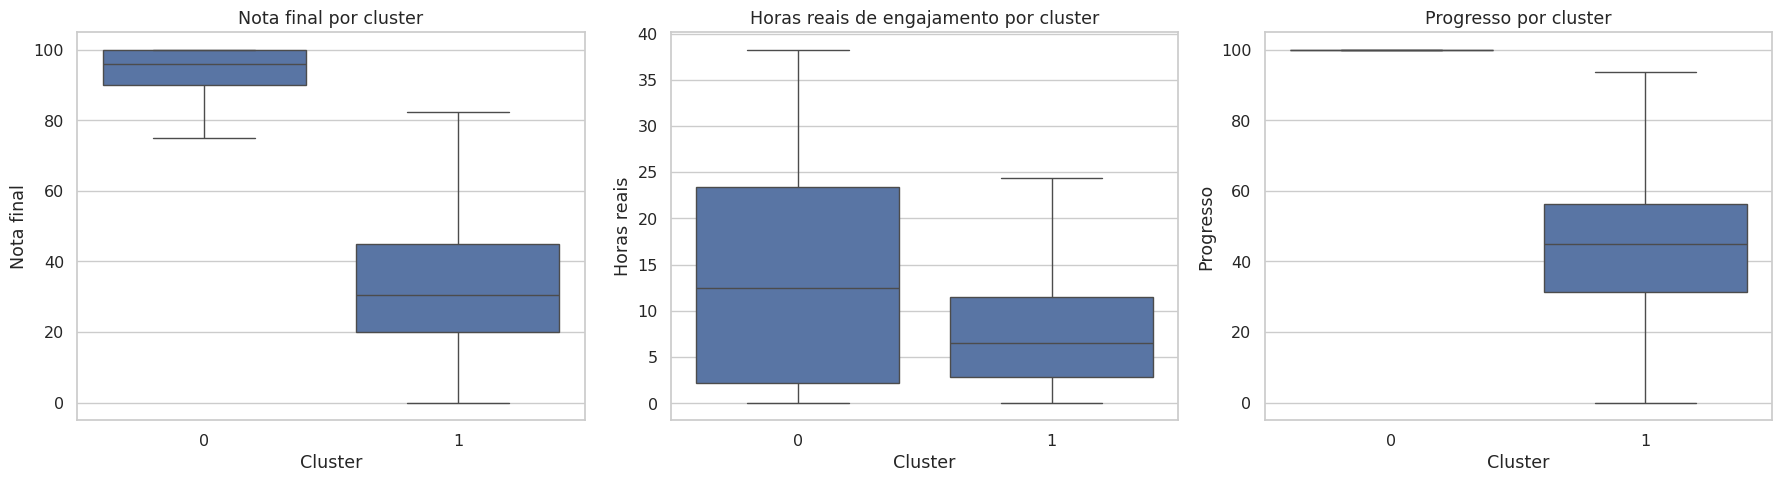

In [ ]:
df_plot = df_exp.copy()

# detecta a coluna de tempo real ou log de minutos
tempo_candidates = ["minutostotaislog1p", "minutos_totais_log1p"]
tempo_col = next((c for c in tempo_candidates if c in df_plot.columns), None)

if tempo_col is None:
    raise KeyError(f"Nenhuma coluna de tempo encontrada. Procuradas: {tempo_candidates}")

df_plot["horas_reais_engajamento"] = np.expm1(df_plot[tempo_col]) / 60

# detecta a coluna de progresso
progresso_candidates = ["progressokdd", "progresso_kdd", "progresso"]
progresso_col = next((c for c in progresso_candidates if c in df_plot.columns), None)

if progresso_col is None:
    raise KeyError(f"Nenhuma coluna de progresso encontrada. Procuradas: {progresso_candidates}")

# detecta a coluna de nota
nota_candidates = ["notafinalkdd", "nota_final_kdd", "nota_final"]
nota_col = next((c for c in nota_candidates if c in df_plot.columns), None)

if nota_col is None:
    raise KeyError(f"Nenhuma coluna de nota encontrada. Procuradas: {nota_candidates}")

if "cluster_final" not in df_plot.columns:
    raise KeyError("A coluna 'cluster_final' não existe em df_plot.")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df_plot, x="cluster_final", y=nota_col, ax=axes[0], showfliers=False)
axes[0].set_title("Nota final por cluster")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Nota final")

sns.boxplot(data=df_plot, x="cluster_final", y="horas_reais_engajamento", ax=axes[1], showfliers=False)
axes[1].set_title("Horas reais de engajamento por cluster")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Horas reais")

sns.boxplot(data=df_plot, x="cluster_final", y=progresso_col, ax=axes[2], showfliers=False)
axes[2].set_title("Progresso por cluster")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("Progresso")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "boxplots_clusters_finais.png", dpi=300, bbox_inches="tight")
plt.show()

### 13.4.Discussão dos boxplots por cluster

Os boxplots reforçam visualmente a separação substantiva entre os dois clusters identificados pelo modelo. Em conjunto, os três painéis mostram que os agrupamentos diferem de forma consistente nas dimensões de desempenho acadêmico, intensidade de engajamento e progresso no curso, o que confirma que a solução em `K = 2` não se limita a uma distinção geométrica abstrata, mas traduz padrões educacionais efetivamente distintos.

No painel de nota final, o cluster 0 apresenta distribuição concentrada em valores altos, com mediana próxima do teto da escala e dispersão relativamente contida. Já o cluster 1 exibe mediana muito inferior e maior espalhamento relativo, incluindo valores bastante baixos. Essa configuração indica que o cluster 0 reúne cursistas com trajetória de alto aproveitamento, enquanto o cluster 1 agrega percursos com desempenho mais heterogêneo e, em sua tendência central, substancialmente inferior.

O painel de horas reais de engajamento acrescenta uma dimensão comportamental decisiva à interpretação. O cluster 0 apresenta mediana superior e maior amplitude, sugerindo não apenas mais tempo total de dedicação, mas também uma presença mais prolongada e efetiva no ambiente formativo. O cluster 1, por outro lado, concentra-se em valores mais baixos, o que é coerente com uma trajetória de menor investimento temporal e menor sustentação do vínculo com a formação.

No gráfico de progresso, a separação torna-se ainda mais clara. O cluster 0 aparece fortemente comprimido junto ao patamar máximo de progresso, evidenciando elevada concentração de cursistas que completaram integralmente a jornada de aprendizagem. Em contraste, o cluster 1 apresenta mediana intermediária e maior dispersão, com casos variando desde ausência quase completa de avanço até níveis próximos da conclusão. Essa heterogeneidade interna é compatível com a ideia de um grupo marcado por atrito formativo, interrupções parciais ou percursos incompletos.

A leitura integrada dos três painéis é particularmente importante. O cluster 0 não se destaca apenas por ter nota mais alta, mas por combinar simultaneamente maior progresso e maior tempo de engajamento. Isso sugere um perfil coeso de participação bem-sucedida, no qual esforço, permanência e resultado acadêmico convergem. Já o cluster 1 combina menor progresso, menor tempo de engajamento e pior desempenho, configurando um padrão também coerente, embora de sentido oposto.

Outro ponto relevante é que os boxplots mostram diferenças não apenas nas medianas, mas também na estrutura de dispersão dos grupos. O cluster 0 tende a ser mais concentrado em torno de trajetórias de sucesso, especialmente no progresso, enquanto o cluster 1 revela maior variabilidade interna, sobretudo em nota e progresso. Isso sugere que o segundo agrupamento abriga um espectro mais amplo de experiências de dificuldade, desde casos de engajamento muito baixo até cursistas que avançam parcialmente, mas não convertem esse percurso em desempenho equivalente ao do grupo majoritário.

Do ponto de vista metodológico, essa evidência visual funciona como uma validação interpretativa do modelo. Depois de a escolha de `K = 2` ter sido sustentada por métricas internas e pela comparação entre cenário com e sem PCA, os boxplots mostram que os clusters também são distinguíveis em variáveis substantivas diretamente compreensíveis. Em outras palavras, a solução ótima é não apenas estatisticamente defensável, mas também pedagogicamente inteligível.

Esses resultados sustentam a nomeação substantiva dos agrupamentos. O cluster 0 pode ser interpretado como um perfil de engajamento pleno e alta eficiência formativa, ao passo que o cluster 1 se aproxima de um perfil de atrito intermediário e conclusão fragilizada. A figura, portanto, cumpre um papel central na narrativa do experimento: ela transforma a partição matemática em evidência visual de que existem, na Rota B, pelo menos dois regimes distintos de participação e desempenho.

### 13.5.Projeção visual do espaço final

Se o cenário final usar PCA e houver pelo menos duas componentes, esta célula produz uma projeção bidimensional útil para inspeção geométrica e para eventual figura do artigo.

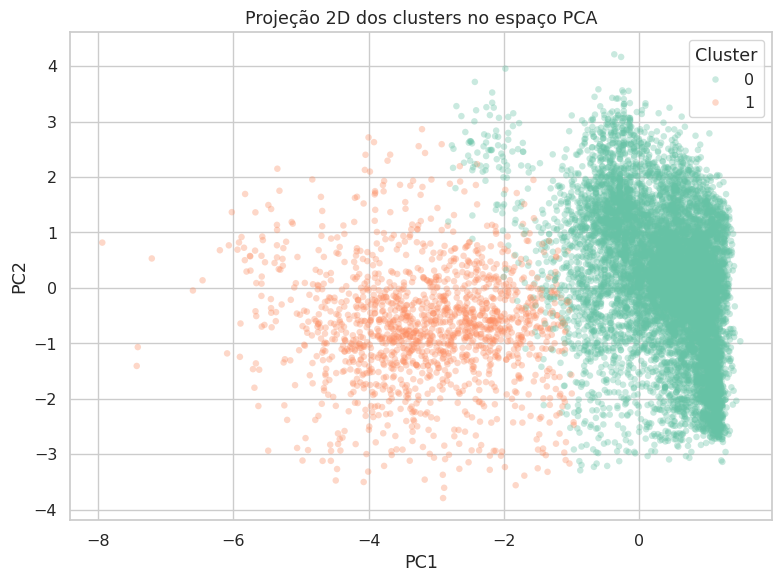

In [ ]:
if CENARIO_FINAL == "Com PCA" and X_pca.shape[1] >= 2:
    amostra = df_exp.sample(min(len(df_exp), 12000), random_state=SEED).copy()
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=amostra,
        x="PC1", y="PC2", hue="cluster_final",
        palette="Set2", alpha=0.35, s=22, linewidth=0
    )
    plt.title("Projeção 2D dos clusters no espaço PCA")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(title="Cluster")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "scatter_pca_clusters.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("Visualização PCA não aplicada ao cenário final.")

### 13.6.Discussão da projeção 2D dos clusters no espaço PCA

A projeção bidimensional dos dados no espaço das duas primeiras componentes principais fornece uma evidência visual importante da estrutura identificada pelo K-Means. Embora a clusterização tenha sido realizada no subespaço PCA completo retido pelo critério de variância, a visualização em PC1 e PC2 já permite observar que os dois agrupamentos ocupam regiões distintas do espaço transformado, o que reforça a consistência geométrica da solução final.

O principal eixo de separação entre os clusters parece ocorrer ao longo da primeira componente principal. O cluster 1 concentra-se predominantemente em valores mais negativos de PC1, formando uma nuvem deslocada para a esquerda da figura, enquanto o cluster 0 ocupa majoritariamente a faixa central e direita do gráfico. Esse padrão sugere que a primeira componente sintetiza uma parte relevante da variabilidade responsável por distinguir trajetórias de maior completude e eficiência daquelas marcadas por menor progresso e maior atrito.

Ao mesmo tempo, a projeção mostra que a separação entre os grupos não é absolutamente rígida. Existe uma zona de sobreposição parcial entre as nuvens, especialmente nas faixas intermediárias de PC1 e em determinados intervalos de PC2. Esse comportamento é esperado em dados educacionais reais, nos quais as trajetórias não se distribuem em compartimentos perfeitamente estanques. A existência de interseção local não invalida a solução; ao contrário, indica que o modelo está operando sobre um fenômeno social contínuo, no qual há casos limítrofes e perfis híbridos.

A segunda componente principal parece atuar mais como eixo de espalhamento interno do que como fronteira primária de separação. Ambos os clusters apresentam dispersão considerável ao longo de PC2, o que indica heterogeneidade intracluster mesmo após a definição dos dois perfis centrais. Isso é metodologicamente relevante porque mostra que cada cluster não deve ser interpretado como uma categoria homogênea absoluta, mas como uma região de maior densidade em torno de um padrão dominante de comportamento.

Outro aspecto importante da figura é a diferença de densidade entre os agrupamentos. O cluster 0 aparece visualmente mais volumoso e concentrado, o que é coerente com sua predominância numérica na base. Já o cluster 1, embora menor, forma uma nuvem suficientemente estruturada para justificar sua interpretação como agrupamento substantivo e não como simples resíduo geométrico.

A disposição espacial observada é compatível com a leitura substantiva já obtida a partir das métricas centrais de profiling. O cluster visualmente mais à esquerda tende a corresponder ao grupo com menor nota, menor progresso e menor tempo de engajamento, enquanto a massa mais à direita está associada ao perfil de maior desempenho e maior completude. Assim, a figura funciona como ponte entre a validação matemática do modelo e sua interpretação pedagógica.

Do ponto de vista metodológico, essa projeção também ajuda a justificar o uso do PCA como etapa prévia à clusterização. A transformação ortogonal organizou a variabilidade da base em eixos mais informativos, tornando visível uma estrutura de separação que seria mais difícil de inspecionar no espaço original de maior dimensionalidade. A figura, portanto, não é apenas ilustrativa, mas evidencia que a redução dimensional preservou conteúdo analítico relevante para a distinção entre os perfis.

Em síntese, a projeção 2D no plano `PC1 x PC2` mostra que a solução em `K = 2` possui respaldo visual consistente: os clusters apresentam separação predominante, densidades distintas e sobreposição apenas parcial. Essa configuração é coerente com a natureza do problema educacional analisado e fortalece a interpretação de que a modelagem identificou dois regimes principais de participação e desempenho dentro da Rota B.

### 13.7. Geração de texto-base para a seção de resultados

A célula abaixo produz um texto auxiliar, em linguagem acadêmica, para servir de rascunho da subseção de resultados do artigo.

In [ ]:
linha_final = tabela_artigo[tabela_artigo["cenario"] == CENARIO_FINAL].iloc[0]
texto_resultados = f"""
No experimento conduzido sobre a Rota B, a comparação entre os cenários com e sem redução de dimensionalidade mostrou que o cenário {CENARIO_FINAL} operou com {int(linha_final["dimensoes_entrada"])} dimensões de entrada e apresentou tempo de treinamento de {linha_final["tempo_segundos"]:.4f} segundos para K={int(linha_final["k"])}. Nesse mesmo ponto decisório, o coeficiente médio de silhueta foi {linha_final["silhueta"]:.4f}, o índice de Davies-Bouldin foi {linha_final["davies_bouldin"]:.4f} e o índice de Calinski-Harabasz atingiu {linha_final["calinski_harabasz"]:.2f}. Esses resultados oferecem base empírica para discutir a relação entre compactação do espaço vetorial, custo computacional e qualidade geométrica dos agrupamentos.
""".strip()

print(texto_resultados)

No experimento conduzido sobre a Rota B, a comparação entre os cenários com e sem redução de dimensionalidade mostrou que o cenário Com PCA operou com 7 dimensões de entrada e apresentou tempo de treinamento de 0.2469 segundos para K=2. Nesse mesmo ponto decisório, o coeficiente médio de silhueta foi 0.3770, o índice de Davies-Bouldin foi 1.2835 e o índice de Calinski-Harabasz atingiu 8644.98. Esses resultados oferecem base empírica para discutir a relação entre compactação do espaço vetorial, custo computacional e qualidade geométrica dos agrupamentos.


No experimento conduzido sobre a Rota B, a comparação entre os cenários com e sem redução de dimensionalidade mostrou que o cenário Com PCA operou com 7 dimensões de entrada e apresentou tempo de treinamento de 0.2469 segundos para K=2. Nesse mesmo ponto decisório, o coeficiente médio de silhueta foi 0.3770, o índice de Davies-Bouldin foi 1.2835 e o índice de Calinski-Harabasz atingiu 8644.98. Esses resultados oferecem base empírica para discutir a relação entre compactação do espaço vetorial, custo computacional e qualidade geométrica dos agrupamentos.


## 14.Exportação dos artefatos do experimento

Serão exportados:

- métricas completas por cenário e por `K`;
- quadro de escolha dos critérios;
- tabela final do artigo;
- profiling dos clusters;
- base analítica da Rota B com rótulos finais;
- sumário do PCA;
- texto-base dos resultados;
- metadados de reprodutibilidade.

In [ ]:
resultados.to_csv(OUTPUT_DIR / "metricas_kmeans_sem_pca_vs_com_pca.csv", index=False, encoding="utf-8")
quadro_escolha.to_csv(OUTPUT_DIR / "quadro_escolha_criterios.csv", index=False, encoding="utf-8")
tabela_artigo.to_csv(OUTPUT_DIR / "tabela_artigo_comparacao_cenarios.csv", index=False, encoding="utf-8")
perfil.reset_index().to_csv(OUTPUT_DIR / "profiling_clusters_finais.csv", index=False, encoding="utf-8")
df_exp.to_csv(OUTPUT_DIR / "rotab_clusterizada_experimento_artigo.csv", index=False, encoding="utf-8")
pca_summary.to_csv(OUTPUT_DIR / "pca_sumario_variancia.csv", index=False, encoding="utf-8")
dist_clusters.to_csv(OUTPUT_DIR / "distribuicao_clusters_finais.csv", index=False, encoding="utf-8")

with open(OUTPUT_DIR / "texto_base_resultados_artigo.txt", "w", encoding="utf-8") as f:
    f.write(texto_resultados)

metadata = {
    "parquet_path": PARQUET_PATH,
    "google_drive_folder_url": GOOGLE_DRIVE_FOLDER_URL,
    "seed": SEED,
    "rota_analitica": "Rota B",
    "filtro_rota_b": "flgnotaimputada == 0 and flgtempoimputado == 0",
    "features": features,
    "cenario_final": CENARIO_FINAL,
    "k_final": int(K_FINAL),
    "n_registros_abt_total": int(df.shape[0]),
    "n_registros_rota_b": int(df_rotab.shape[0]),
    "n_features_originais": int(X.shape[1]),
    "n_componentes_pca": int(X_pca.shape[1]),
    "variancia_retida_pca": float(pca.explained_variance_ratio_.sum())
}

with open(OUTPUT_DIR / "metadata_experimento_artigo.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("Artefatos exportados em:", OUTPUT_DIR)
print(sorted([p.name for p in OUTPUT_DIR.iterdir()]))

Artefatos exportados em: /content/output
['benchmark_memoria_kmeans.png', 'boxplots_clusters_finais.png', 'comparativo_metricas_kmeans_sem_pca_vs_com_pca.png', 'distribuicao_clusters_finais.csv', 'escalabilidade_temporal_kmeans.png', 'estabilidade_kmeans_sementes.png', 'figura_eproxy_comparativo.png', 'inventario_artefatos_artigo.csv', 'metadata_experimento_artigo.json', 'metricas_kmeans_sem_pca_vs_com_pca.csv', 'painel_histogramas_variaveis_rota_b.png', 'pca_sumario_variancia.csv', 'pca_variancia_acumulada.png', 'profiling_clusters_finais.csv', 'proxy_eficiencia_energetica_eproxy.csv', 'quadro_escolha_criterios.csv', 'rotab_clusterizada_experimento_artigo.csv', 'scatter_pca_clusters.png', 'sintese_eficiencia_operacional.csv', 'tabela_artigo_comparacao_cenarios.csv', 'texto_base_resultados_artigo.txt']


### 14.1.Exportação consolidada dos resultados

A célula a seguir deve ser executada ao final do notebook e realiza automaticamente as seguintes tarefas:

1. localiza todos os arquivos gerados em `OUTPUTDIR`;
2. cria um arquivo consolidado em Markdown;
3. registra metadados básicos de reprodutibilidade do ambiente e dos artefatos;
4. cria um arquivo `.zip` com todos os resultados da execução;
5. inicia o download automático do `.zip` quando executado no Google Colab.

In [ ]:
from pathlib import Path
import os
import io
import json
import zipfile
import hashlib
import mimetypes
import platform
import sys
from datetime import datetime

import pandas as pd

# =========================================================
# 1) Diretório de saída
# =========================================================
output_dir = Path(globals().get("OUTPUTDIR", "output"))
output_dir = Path(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

# =========================================================
# 2) Configurações
# =========================================================
TEXT_EXTS = {
    ".txt", ".md", ".json", ".yaml", ".yml", ".log", ".tex",
    ".py", ".sql", ".html", ".htm", ".xml"
}
TABLE_EXTS = {".csv", ".tsv", ".xlsx", ".xls"}
MAX_TEXT_CHARS = 200_000
MAX_TABLE_ROWS = 300

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
consolidated_file = output_dir / f"saida_unificada_{timestamp}.md"
manifest_file = output_dir / f"manifesto_reprodutibilidade_{timestamp}.json"
zip_file = output_dir / f"artefatos_execucao_{timestamp}.zip"

# =========================================================
# 3) Funções auxiliares
# =========================================================
def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

def read_text_safe(path: Path, max_chars=MAX_TEXT_CHARS):
    text = path.read_text(encoding="utf-8", errors="replace")
    truncated = len(text) > max_chars
    if truncated:
        text = text[:max_chars] + "\n\n[TRUNCADO PARA LEITURA CONSOLIDADA]"
    return text, truncated

def dataframe_to_markdown(df: pd.DataFrame, max_rows=MAX_TABLE_ROWS) -> str:
    if len(df) > max_rows:
        head_n = max_rows // 2
        tail_n = max_rows - head_n
        df_show = pd.concat([df.head(head_n), df.tail(tail_n)], axis=0)
        note = f"\n\n[TABELA TRUNCADA: mostrando {head_n} primeiras e {tail_n} últimas linhas de {len(df)} linhas]\n"
    else:
        df_show = df
        note = ""
    try:
        md = df_show.to_markdown(index=False)
    except Exception:
        md = df_show.to_csv(index=False)
    return md + note

def pkg_version(pkg_name: str):
    try:
        import importlib.metadata as im
        return im.version(pkg_name)
    except Exception:
        return None

# =========================================================
# 4) Coleta dos arquivos
# =========================================================
all_files = sorted(
    [p for p in output_dir.rglob("*") if p.is_file()]
)

# Evita incluir artefatos desta própria exportação em listagens prévias
all_files = [p for p in all_files if p.name not in {consolidated_file.name, manifest_file.name, zip_file.name}]

# =========================================================
# 5) Manifesto de ambiente
# =========================================================
manifest = {
    "timestamp_exportacao": datetime.now().isoformat(),
    "python_version": sys.version,
    "platform": platform.platform(),
    "output_dir": str(output_dir.resolve()),
    "seed_global": globals().get("SEED", None),
    "pacotes": {
        "pandas": pkg_version("pandas"),
        "numpy": pkg_version("numpy"),
        "scikit-learn": pkg_version("scikit-learn"),
        "matplotlib": pkg_version("matplotlib"),
        "seaborn": pkg_version("seaborn"),
        "scipy": pkg_version("scipy"),
    },
    "arquivos": []
}

# =========================================================
# 6) Consolidação em Markdown
# =========================================================
sections = []
sections.append("# Saída consolidada da execução\n")
sections.append(f"- Gerado em: {datetime.now().isoformat()}\n")
sections.append(f"- Diretório de saída: `{output_dir.resolve()}`\n")
if globals().get("SEED", None) is not None:
    sections.append(f"- Semente global detectada: `{globals().get('SEED')}`\n")

sections.append("\n## Inventário dos artefatos\n")

for path in all_files:
    rel = path.relative_to(output_dir)
    mime = mimetypes.guess_type(str(path))[0] or "application/octet-stream"
    size = path.stat().st_size
    sha = sha256_file(path)

    file_info = {
        "arquivo": str(rel),
        "mime": mime,
        "bytes": size,
        "sha256": sha,
    }
    manifest["arquivos"].append(file_info)

    sections.append(f"\n### {rel}\n")
    sections.append(f"- MIME: `{mime}`\n")
    sections.append(f"- Tamanho (bytes): `{size}`\n")
    sections.append(f"- SHA256: `{sha}`\n")

    suffix = path.suffix.lower()

    if suffix in TABLE_EXTS:
        try:
            if suffix == ".csv":
                df = pd.read_csv(path)
                sections.append("\n#### Conteúdo tabular\n")
                sections.append(dataframe_to_markdown(df) + "\n")
            elif suffix == ".tsv":
                df = pd.read_csv(path, sep="\t")
                sections.append("\n#### Conteúdo tabular\n")
                sections.append(dataframe_to_markdown(df) + "\n")
            elif suffix in {".xlsx", ".xls"}:
                xls = pd.ExcelFile(path)
                sections.append("\n#### Planilha\n")
                sections.append(f"- Abas detectadas: {', '.join(xls.sheet_names)}\n")
                for sheet in xls.sheet_names:
                    try:
                        df = pd.read_excel(path, sheet_name=sheet)
                        sections.append(f"\n##### Aba: {sheet}\n")
                        sections.append(dataframe_to_markdown(df) + "\n")
                    except Exception as e:
                        sections.append(f"\n[Não foi possível ler a aba `{sheet}`: {e}]\n")
        except Exception as e:
            sections.append(f"\n[Erro ao ler tabela `{rel}`: {e}]\n")

    elif suffix in TEXT_EXTS:
        try:
            text, truncated = read_text_safe(path)
            sections.append("\n#### Conteúdo textual\n")
            sections.append("```text\n")
            sections.append(text)
            sections.append("\n```\n")
            if truncated:
                sections.append("\n[Observação: arquivo truncado para manter o consolidado manejável.]\n")
        except Exception as e:
            sections.append(f"\n[Erro ao ler arquivo textual `{rel}`: {e}]\n")

    else:
        sections.append(
            "\n#### Artefato binário\n"
            "Este arquivo foi incluído no `.zip`, mas não foi incorporado integralmente ao documento consolidado.\n"
        )

# =========================================================
# 7) Escrita dos arquivos consolidados
# =========================================================
consolidated_file.write_text("\n".join(sections), encoding="utf-8")

with open(manifest_file, "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)

# =========================================================
# 8) Geração do ZIP
# =========================================================
with zipfile.ZipFile(zip_file, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for path in all_files:
        zf.write(path, arcname=path.relative_to(output_dir))
    zf.write(consolidated_file, arcname=consolidated_file.name)
    zf.write(manifest_file, arcname=manifest_file.name)

print(f"Arquivo consolidado: {consolidated_file}")
print(f"Manifesto de reprodutibilidade: {manifest_file}")
print(f"ZIP final: {zip_file}")
print(f"Total de arquivos incluídos no ZIP: {len(all_files) + 2}")

# =========================================================
# 9) Download automático no Google Colab
# =========================================================
try:
    from google.colab import files
    files.download(str(zip_file))
    print("Download automático iniciado no Google Colab.")
except Exception as e:
    print("Ambiente fora do Google Colab ou download automático indisponível.")
    print(f"Faça o download manual do arquivo: {zip_file}")
    print(f"Detalhe técnico: {e}")

Arquivo consolidado: output/saida_unificada_20260627_131938.md
Manifesto de reprodutibilidade: output/manifesto_reprodutibilidade_20260627_131938.json
ZIP final: output/artefatos_execucao_20260627_131938.zip
Total de arquivos incluídos no ZIP: 23


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download automático iniciado no Google Colab.


## 15.Encerramento metodológico

Este notebook consolida um experimento reproduzível orientado à redação do artigo, estruturado para transformar a análise da Rota B em um fluxo verificável, documentado e reutilizável. Ao longo do pipeline, a ABT consolidada foi reaproveitada como base única de entrada, a comparação entre cenários com e sem redução de dimensionalidade foi conduzida de forma controlada, as métricas de qualidade geométrica, estabilidade e custo computacional foram registradas explicitamente, e os principais artefatos analíticos foram exportados para uso direto no manuscrito.

Do ponto de vista metodológico, o experimento foi organizado para sustentar a decisão final com base empírica e rastreável. A comparação entre **K-Means sem PCA** e **K-Means com PCA** permitiu avaliar, no mesmo ambiente analítico, o efeito da compactação do espaço vetorial sobre a estrutura dos agrupamentos, o custo de treinamento, a estabilidade entre execuções e a interpretabilidade dos resultados.

Esse desenho fortalece a consistência interna do estudo porque evita decisões isoladas ou pouco documentadas. Em vez de selecionar a configuração final apenas por conveniência operacional, o pipeline articula critérios quantitativos de validação interna, evidências de eficiência computacional, indicadores compostos de apoio à decisão e materiais exportáveis que apoiam tanto a análise substantiva quanto a escrita científica.

A etapa final de exportação também amplia a reprodutibilidade do experimento. Com a preservação das tabelas comparativas, do profiling dos clusters, da base rotulada, do sumário do PCA, do texto-base dos resultados e dos metadados técnicos, o notebook passa a funcionar não apenas como ambiente de execução, mas como registro formal da trajetória analítica que fundamenta o artigo.

### 15.1. Compromissos metodológicos do experimento

- reaproveitamento rigoroso da ABT consolidada como fonte única da análise;
- comparação controlada entre **K-Means sem PCA** e **K-Means com PCA**;
- mensuração explícita de qualidade geométrica, tempo de treinamento, memória e estabilidade dos agrupamentos;
- consolidação multicritério da escolha do cenário final, incluindo evidências operacionais e proxy de eficiência;
- exportação de artefatos reutilizáveis na redação, documentação e reprodutibilidade do manuscrito.

### 15.2. Sugestão de uso no artigo

- usar a tabela-síntese final de comparação entre cenários como quadro principal da decisão metodológica no `K` selecionado;
- usar a figura comparativa das métricas do K-Means como visual central do experimento, destacando desempenho e qualidade geométrica ao longo dos valores de `K`;
- usar os arquivos de distribuição e profiling dos clusters finais na subseção de interpretação dos perfis, articulando diferenças entre os agrupamentos finais;
- usar o texto-base gerado para a seção de resultados como apoio à redação inicial do manuscrito, sempre com revisão posterior;
- anexar os metadados do experimento e os artefatos consolidados ao repositório do projeto, reforçando transparência metodológica e reprodutibilidade.

Observação metodológica: este encerramento resume a estrutura e os produtos da execução atual do notebook, mas os artefatos, valores e ênfases analíticas podem mudar em novas execuções ou refinamentos do pipeline. Por isso, a redação final desta seção deve sempre ser conferida à luz da versão efetivamente exportada dos resultados e dos arquivos gerados no experimento corrente.